# NB05 — YOLO11s Training & Evaluation (All-in-One)

> **Pipeline position:** NB04 (YOLO11n) → **NB05 (YOLO11s)** → NB06 (RT-DETR)

## What this notebook does (all in one place)

| Section | Purpose |
|---|---|
| 0. Setup | Imports, paths, config from `training_config.json` |
| 0b. GPU Purge | Kill all leftover GPU tensors — ensures full VRAM available |
| 1. Pre-flight | GPU check, VRAM-safe batch, file validation |
| 2. Training | YOLO11s 100-epoch run with monitoring callbacks |
| 3. Training curves | 6-panel loss/metric plots from `results.csv` |
| 4. YOLO plots | F1, PR, confusion matrix, sample predictions |
| 5. Checkpoint eval | Per-class AP50 at key epochs + best |
| 6. Ablation gate | Minority class decision (vest / no-vest) |
| 7. Final eval | Val + test → `nb07_model_comparison.csv` |

## Context from NB04 (YOLO11n baseline)

| Item | Value |
|---|---|
| YOLO11n best mAP50 | 0.9053 (epoch 77/100) |
| Minority avg AP50 | 0.8942 — no ablation needed |
| GPU | RTX 4060 Laptop, 8.6 GB VRAM |
| YOLO11s config | **batch=4**, imgsz=1280, nbs=64, half=True, **workers=4** |

### Why batch=4 (not 6 like NB04)
- YOLO11s has ~3.6x more params than YOLO11n
- batch=6 at imgsz=1280 → **7.3G VRAM** → only 1.3G free
- cuDNN needs free VRAM for convolution workspace — with <2G free it falls back to **10x slower algorithms**
- batch=4 → ~5G VRAM → ~3.6G free → cuDNN uses fast algorithms
- Effective batch stays 64 via accumulate=16 — no impact on convergence

### Lessons learned
- `torch.cuda.empty_cache()` alone is NOT enough — must `gc.collect()` + `ipc_collect()` + delete old model refs
- **CRITICAL**: Restart kernel before re-running training — old model objects hog VRAM
- cuDNN algorithm selection depends on free VRAM — too little headroom = catastrophic slowdown

In [1]:
# ============================================================
# 0. IMPORTS & CONFIG
# ============================================================
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display, Image as IPImage

import torch
from ultralytics import YOLO

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ---- Paths (CWD = notebooks/) ----
PROJECT_ROOT = Path('../')
DATA_YAML    = PROJECT_ROOT / 'data' / 'ppe_dataset.yaml'
HYP_YAML     = PROJECT_ROOT / 'data' / 'hyp_ppe.yaml'
CFG_JSON     = PROJECT_ROOT / 'data' / 'training_config.json'
RESULTS_DIR  = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# Ultralytics saves runs under CWD, which is notebooks/
# Both locations are checked throughout this notebook
RUNS_DIR_CWD  = Path('runs/detect')           # notebooks/runs/detect/
RUNS_DIR_PROJ = PROJECT_ROOT / 'runs' / 'detect'  # project root/runs/detect/

CLASS_NAMES  = ['hardhat', 'no-hardhat', 'vest', 'no-vest', 'person']
MINORITY_CLS = ['vest', 'no-vest']

# ---- Load config ----
with open(CFG_JSON) as f:
    ALL_CONFIGS = json.load(f)
cfg = ALL_CONFIGS['yolo11s']

print('YOLO11s Configuration:')
for k, v in cfg.items():
    print(f'  {k:<20}: {v}')

print(f'\nProject root : {PROJECT_ROOT.resolve()}')
print(f'Data YAML    : {DATA_YAML.resolve()}')
print(f'Hyp YAML     : {HYP_YAML.resolve()}')

YOLO11s Configuration:
  imgsz               : 1280
  batch               : 4
  nbs                 : 64
  half                : True
  cache               : False
  workers             : 4
  grad_checkpoint     : False
  name                : ppe_yolo11s_1280

Project root : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection
Data YAML    : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\ppe_dataset.yaml
Hyp YAML     : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\hyp_ppe.yaml


In [2]:
# ============================================================
# 0b. AGGRESSIVE GPU MEMORY PURGE
# ============================================================
# Kill any leftover tensors/models from previous cells or runs.
# This ensures training gets the full 8.6 GB VRAM.
# ============================================================
import gc

# Delete any model objects lingering in the global namespace
for _var_name in list(globals().keys()):
    _obj = globals()[_var_name]
    if hasattr(_obj, 'model') or (hasattr(type(_obj), '__module__') and
       'ultralytics' in str(getattr(type(_obj), '__module__', ''))):
        try:
            del globals()[_var_name]
        except Exception:
            pass

# Force Python garbage collection
gc.collect()

# Clear all CUDA cached memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    vram_alloc = torch.cuda.memory_allocated(0) / 1e9
    vram_reserved = torch.cuda.memory_reserved(0) / 1e9
    print(f'GPU Memory after purge:')
    print(f'  Total     : {vram_total:.2f} GB')
    print(f'  Allocated : {vram_alloc:.4f} GB')
    print(f'  Reserved  : {vram_reserved:.4f} GB')
    print(f'  Free      : {vram_total - vram_alloc:.2f} GB')
else:
    print('CUDA not available!')

GPU Memory after purge:
  Total     : 8.59 GB
  Allocated : 0.0000 GB
  Reserved  : 0.0000 GB
  Free      : 8.59 GB


In [3]:
# ============================================================
# 1. PRE-FLIGHT CHECKS
# ============================================================
import gc

print('=' * 58)
print('  PRE-FLIGHT CHECKS — YOLO11s')
print('=' * 58)

# --- GPU ---
assert torch.cuda.is_available(), 'CUDA not available — check driver'
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = (torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_allocated(0)) / 1e9
print(f'  GPU        : {torch.cuda.get_device_name(0)}')
print(f'  VRAM       : {vram_total:.1f} GB total  |  {vram_free:.1f} GB free')

# --- Batch & workers ---
# YOLO11s at batch=6, imgsz=1280 uses 7.3G of 8.6G VRAM.
# This leaves only ~1.3G free — cuDNN falls back to SLOW convolution
# algorithms because it lacks workspace memory. Result: 2+ hrs/epoch.
#
# batch=4 drops VRAM to ~5G, giving cuDNN ~3.6G workspace.
# Fast algorithms run ~10x faster per iteration. Even with more
# iterations (3870 vs 2580), wall-clock per epoch drops to ~15-20 min.
# Effective batch stays 64 via accumulate=16.
SAFE_BATCH   = cfg['batch']     # 4 — cuDNN needs VRAM headroom
SAFE_WORKERS = cfg['workers']   # 4 — keep GPU fed

accumulate = cfg['nbs'] // SAFE_BATCH
print(f'  Batch      : {SAFE_BATCH} (effective {cfg["nbs"]} via accumulate={accumulate})')
print(f'  Workers    : {SAFE_WORKERS}')

# --- Aggressive GPU purge ---
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()
vram_after = (torch.cuda.get_device_properties(0).total_memory
              - torch.cuda.memory_allocated(0)) / 1e9
print(f'  Cache clear: {vram_free:.1f} -> {vram_after:.1f} GB free')

# --- Files ---
for label, path in [('Dataset YAML', DATA_YAML),
                     ('Hyp YAML',     HYP_YAML),
                     ('Config JSON',  CFG_JSON)]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  {label:<14}: {status}  {path}')
    assert path.exists(), f'{label} not found at {path.resolve()}'

# --- Dataset quick count ---
train_dir = PROJECT_ROOT / 'data' / 'processed' / 'images' / 'train'
val_dir   = PROJECT_ROOT / 'data' / 'processed' / 'images' / 'val'
test_dir  = PROJECT_ROOT / 'data' / 'processed' / 'images' / 'test'

train_count = len(list(train_dir.glob('*.*')))
val_count   = len(list(val_dir.glob('*.*')))
test_count  = len(list(test_dir.glob('*.*')))
print(f'  Train imgs : {train_count:,}')
print(f'  Val imgs   : {val_count:,}')
print(f'  Test imgs  : {test_count:,}')

print('=' * 58)
print('  All checks passed — ready to train')
print('=' * 58)

  PRE-FLIGHT CHECKS — YOLO11s
  GPU        : NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM       : 8.6 GB total  |  8.6 GB free
  Batch      : 4 (effective 64 via accumulate=16)
  Workers    : 4
  Cache clear: 8.6 -> 8.6 GB free
  Dataset YAML  : OK  ..\data\ppe_dataset.yaml
  Hyp YAML      : OK  ..\data\hyp_ppe.yaml
  Config JSON   : OK  ..\data\training_config.json
  Train imgs : 15,480
  Val imgs   : 1,086
  Test imgs  : 1,087
  All checks passed — ready to train


---
## 2. Training

> Estimated ~20-24h on RTX 4060 Laptop (YOLO11s is ~2x YOLO11n parameters).  
> Callbacks log aggregate metrics every epoch; per-class AP50 is evaluated post-training.  
> If training crashes (OOM/power), resume with the commented-out cell below.

In [4]:
# ============================================================
# 2a. MONITORING CALLBACKS
# ============================================================
# Alert thresholds (same as NB04)
CLS_LOSS_ALERT_EPOCH5  = 2.0
CLS_LOSS_ALERT_EPOCH20 = 1.5
RECALL_ALERT_EPOCH20   = 0.50
MAP50_GATE_EPOCH20     = 0.55

# Metric log
METRIC_LOG_PATH = RESULTS_DIR / 'nb05_epoch_log.csv'
epoch_log = []

def on_val_end(validator):
    """Runs after every validation pass — logs aggregate metrics + fires alerts."""
    global epoch_log
    epoch = len(epoch_log) + 1

    try:
        metrics   = validator.metrics
        map50     = float(metrics.box.map50)
        map5095   = float(metrics.box.map)
        precision = float(metrics.box.mp)
        recall    = float(metrics.box.mr)
    except Exception:
        map50 = map5095 = precision = recall = 0.0

    # Read losses from results.csv (not available on validator)
    box_loss = cls_loss = dfl_loss = 0.0
    try:
        # Check both possible run locations
        for runs_dir in [RUNS_DIR_CWD, RUNS_DIR_PROJ]:
            candidates = sorted(
                [p for p in runs_dir.iterdir()
                 if p.name.startswith('ppe_yolo11s_1280')],
                key=lambda p: p.stat().st_mtime, reverse=True
            ) if runs_dir.is_dir() else []
            if candidates:
                csv_path = candidates[0] / 'results.csv'
                if csv_path.exists():
                    df_tmp = pd.read_csv(csv_path)
                    df_tmp.columns = df_tmp.columns.str.strip()
                    if len(df_tmp) > 0:
                        last = df_tmp.iloc[-1]
                        box_loss = float(last.get('train/box_loss', 0))
                        cls_loss = float(last.get('train/cls_loss', 0))
                        dfl_loss = float(last.get('train/dfl_loss', 0))
                    break
    except Exception:
        pass

    row = {
        'epoch': epoch, 'map50': map50, 'map5095': map5095,
        'precision': precision, 'recall': recall,
        'box_loss': box_loss, 'cls_loss': cls_loss, 'dfl_loss': dfl_loss,
        'timestamp': datetime.now().isoformat(),
    }
    epoch_log.append(row)
    pd.DataFrame(epoch_log).to_csv(METRIC_LOG_PATH, index=False)

    # ---- Alerts ----
    alerts = []
    if epoch == 5 and cls_loss > CLS_LOSS_ALERT_EPOCH5:
        alerts.append(f'  cls_loss={cls_loss:.3f} > {CLS_LOSS_ALERT_EPOCH5} at ep5')

    if epoch == 20:
        if map50 < MAP50_GATE_EPOCH20:
            alerts.append(f'  mAP50={map50:.3f} < {MAP50_GATE_EPOCH20} at ep20')
        if recall < RECALL_ALERT_EPOCH20:
            alerts.append(f'  recall={recall:.3f} < {RECALL_ALERT_EPOCH20} at ep20')
        if cls_loss > CLS_LOSS_ALERT_EPOCH20:
            alerts.append(f'  cls_loss={cls_loss:.3f} > {CLS_LOSS_ALERT_EPOCH20} at ep20')

    if epoch >= 15 and len(epoch_log) >= 10:
        recent = [r['map50'] for r in epoch_log[-10:]]
        if max(recent) - min(recent) < 0.005:
            alerts.append(f'  mAP50 stagnant for 10 epochs')

    if epoch in {1, 5, 10, 20, 50, 75, 100}:
        print(f'\n  CHECKPOINT ep{epoch}: mAP50={map50:.3f}  recall={recall:.3f}  cls_loss={cls_loss:.3f}')

    for alert in alerts:
        print(f'  ALERT: {alert}')

print(f'Callbacks defined')
print(f'  Metric log -> {METRIC_LOG_PATH}')

Callbacks defined
  Metric log -> ..\results\nb05_epoch_log.csv


In [5]:
# ============================================================
# 2b. TRAINING RUN
# ============================================================
# Aggressive GPU purge — kill everything before allocating the model
import gc

# Delete any previous model references
for _name in ['model', 'final_model', 'ckpt_model']:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

vram_before = (torch.cuda.get_device_properties(0).total_memory
               - torch.cuda.memory_allocated(0)) / 1e9
print(f'VRAM free before model load: {vram_before:.2f} GB')

model = YOLO('yolo11s.pt')
model.add_callback('on_val_end', on_val_end)

print(f'\nStarting YOLO11s training:')
print(f'  imgsz       = {cfg["imgsz"]}')
print(f'  batch       = {SAFE_BATCH}')
print(f'  nbs         = {cfg["nbs"]}  (accumulate = {cfg["nbs"] // SAFE_BATCH})')
print(f'  half (FP16) = {cfg["half"]}')
print(f'  workers     = {SAFE_WORKERS}')
print(f'  epochs      = 100')
print(f'  patience    = 20')
print(f'  save_period = 5')
print()

train_start = time.time()
results = model.train(
    data        = str(DATA_YAML),
    cfg         = str(HYP_YAML),
    imgsz       = cfg['imgsz'],
    batch       = SAFE_BATCH,
    nbs         = cfg['nbs'],
    half        = cfg['half'],
    cache       = False,
    workers     = SAFE_WORKERS,
    epochs      = 100,
    patience    = 20,
    device      = 0,
    name        = cfg['name'],
    save        = True,
    save_period = 5,
    plots       = True,
    val         = True,
    verbose     = True,
)

train_elapsed = time.time() - train_start
print(f'\nTraining complete in {train_elapsed/3600:.1f} hours')

VRAM free before model load: 8.59 GB

Starting YOLO11s training:
  imgsz       = 1280
  batch       = 4
  nbs         = 64  (accumulate = 16)
  half (FP16) = True
  workers     = 4
  epochs      = 100
  patience    = 20
  save_period = 5

New https://pypi.org/project/ultralytics/8.4.30 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolo11s.pt, data=..\data\ppe_dataset.yaml, epochs=100, time=None, patience=20, batch=4, imgsz=1280, save=True, save_period=5, cache=False, device=0, workers=4, project=None, name=ppe_yolo11s_12804, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_js

train: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\train.cache... 15480 images, 0 backgrounds, 0 corrupt: 100%|██████████| 15480/15480 [00:00<?, ?it/s]

train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train\css_construction-682-_jpg.rf.7161480fa0134c8ed4985baec0b325c8_os1.jpg: 1 duplicate labels removed
train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train\shwd_000002.jpg: corrupt JPEG restored and saved
train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train\shwd_000006.jpg: corrupt JPEG restored and saved
train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train\shwd_000007.jpg: corrupt JPEG restored and saved
train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\train\shwd_000011.jpg: corrupt JPEG restored and saved
train: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\val.cache... 1086 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1086/1086 [00:00<?, ?it/s]

...

    100/100      5.79G      1.009     0.5157      1.157         66       1280: 100%|██████████| 3870/3870 [14:12<00:00,  4.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 136/136 [00:18<00:00,  7.39it/s]

                   all       1086      14198      0.935      0.881      0.941      0.666



  CHECKPOINT ep100: mAP50=0.941  recall=0.881  cls_loss=0.520
  ALERT:   mAP50 stagnant for 10 epochs

100 epochs completed in 24.919 hours.
Optimizer stripped from runs\detect\ppe_yolo11s_12804\weights\last.pt, 19.3MB
Optimizer stripped from runs\detect\ppe_yolo11s_12804\weights\best.pt, 19.3MB

Validating runs\detect\ppe_yolo11s_12804\weights\best.pt...
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 238 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 136/136 [00:17<00:00,  7.68it/s]


                   all       1086      14198      0.929      0.885      0.941      0.666
               hardhat        438       1109       0.94      0.876      0.941      0.733
            no-hardhat        638      11186      0.946      0.914      0.968      0.547
                  vest        133        315      0.931      0.886      0.939      0.683
               no-vest        182        377      0.935      0.897      0.951      0.696
                person        343       1211      0.891      0.852      0.908      0.672
  ALERT:   mAP50 stagnant for 10 epochs
Speed: 0.5ms preprocess, 10.0ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\ppe_yolo11s_12804

Training complete in 24.9 hours


In [ ]:
# ============================================================
# 2c. RESUME TRAINING (only if training crashed)
# Uncomment and run this cell INSTEAD of 2b if you need to resume.
# ============================================================
# # Find the latest run folder to resume from
# for runs_dir in [RUNS_DIR_CWD, RUNS_DIR_PROJ]:
#     if not runs_dir.is_dir():
#         continue
#     candidates = sorted(
#         [p for p in runs_dir.iterdir() if p.name.startswith('ppe_yolo11s_1280')],
#         key=lambda p: p.stat().st_mtime, reverse=True
#     )
#     if candidates:
#         last_pt = candidates[0] / 'weights' / 'last.pt'
#         if last_pt.exists():
#             print(f'Resuming from: {last_pt}')
#             torch.cuda.empty_cache()
#             model = YOLO(str(last_pt))
#             model.add_callback('on_val_end', on_val_end)
#             results = model.train(resume=True)
#             print('Resume training complete')
#             break
#     else:
#         print(f'No ppe_yolo11s_1280* runs found in {runs_dir}')
print('Resume cell — skip unless training crashed. Uncomment to use.')

---
## Post-Training Evaluation (Sections 3–7)

> Run all cells below **after training completes**.  
> The run folder is auto-detected — no paths to edit.

In [6]:
# ============================================================
# AUTO-DETECT RUN FOLDER
# Ultralytics saves under CWD (notebooks/) and appends numeric
# suffixes: ppe_yolo11s_1280, ppe_yolo11s_12802, etc.
# This cell finds the latest one with a best.pt checkpoint.
# ============================================================

def find_run_dir(prefix='ppe_yolo11s_1280'):
    """Find the latest run directory matching prefix, preferring one with best.pt."""
    all_candidates = []
    for runs_dir in [RUNS_DIR_CWD, RUNS_DIR_PROJ]:
        if not runs_dir.is_dir():
            continue
        for p in runs_dir.iterdir():
            if p.name.startswith(prefix) and p.is_dir():
                all_candidates.append(p)

    if not all_candidates:
        raise FileNotFoundError(
            f'No {prefix}* runs found.\n'
            f'  Checked: {RUNS_DIR_CWD.resolve()}\n'
            f'           {RUNS_DIR_PROJ.resolve()}'
        )

    # Prefer runs that have best.pt (training completed)
    with_best = [p for p in all_candidates if (p / 'weights' / 'best.pt').exists()]
    pool = with_best if with_best else all_candidates

    # Pick most recently modified
    chosen = max(pool, key=lambda p: p.stat().st_mtime)
    return chosen

RUN_DIR     = find_run_dir()
RUN_NAME    = RUN_DIR.name
WEIGHTS_DIR = RUN_DIR / 'weights'

print(f'Run folder  : {RUN_DIR.resolve()}')
print(f'Run name    : {RUN_NAME}')
print()
print('Weights available:')
for w in sorted(WEIGHTS_DIR.glob('*.pt')):
    size_mb = w.stat().st_size / 1e6
    print(f'  {w.name:<20} {size_mb:.1f} MB')

Run folder  : C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\notebooks\runs\detect\ppe_yolo11s_12804
Run name    : ppe_yolo11s_12804

Weights available:
  best.pt              19.3 MB
  epoch0.pt            38.2 MB
  epoch10.pt           38.2 MB
  epoch15.pt           38.2 MB
  epoch20.pt           38.2 MB
  epoch25.pt           38.2 MB
  epoch30.pt           38.2 MB
  epoch35.pt           38.2 MB
  epoch40.pt           38.2 MB
  epoch45.pt           38.2 MB
  epoch5.pt            38.2 MB
  epoch50.pt           38.2 MB
  epoch55.pt           38.2 MB
  epoch60.pt           38.2 MB
  epoch65.pt           38.2 MB
  epoch70.pt           38.2 MB
  epoch75.pt           38.2 MB
  epoch80.pt           38.2 MB
  epoch85.pt           38.2 MB
  epoch90.pt           38.2 MB
  epoch95.pt           38.2 MB
  last.pt              19.3 MB


---
## 3. Training Curves (from results.csv)

In [7]:
# ============================================================
# 3. TRAINING CURVES — 6-panel plot
# ============================================================
results_csv = RUN_DIR / 'results.csv'
assert results_csv.exists(), f'results.csv not found at {results_csv}'

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_ep    = int(df['metrics/mAP50(B)'].idxmax()) + 1
best_map50 = df['metrics/mAP50(B)'].max()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'Training Curves — {RUN_NAME}\n'
    f'{len(df)} epochs  |  Best mAP50 = {best_map50:.3f} @ epoch {best_ep}',
    fontsize=14, fontweight='bold'
)

plot_configs = [
    ('train/cls_loss',       axes[0, 0], 'Classification Loss',  'cls_loss',  1.5),
    ('train/box_loss',       axes[0, 1], 'Box Regression Loss',  'box_loss',  None),
    ('train/dfl_loss',       axes[0, 2], 'DFL Loss',             'dfl_loss',  None),
    ('metrics/mAP50(B)',     axes[1, 0], 'mAP50 (val)',          'mAP50',     0.55),
    ('metrics/recall(B)',    axes[1, 1], 'Recall (val)',          'Recall',    0.50),
    ('metrics/precision(B)', axes[1, 2], 'Precision (val)',       'Precision', None),
]

epochs = df.index + 1
for col, ax, title, ylabel, alert in plot_configs:
    if col not in df.columns:
        ax.set_title(f'{title}\n(not in results.csv)')
        continue
    ax.plot(epochs, df[col], linewidth=2, color='steelblue')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    if alert is not None:
        ax.axhline(alert, color='red', linestyle='--', alpha=0.7,
                   label=f'Alert ({alert})')
        ax.legend(fontsize=9)
    for ckpt_ep in [5, 10, 20, 50]:
        if ckpt_ep <= len(epochs):
            ax.axvline(ckpt_ep, color='orange', linestyle=':', alpha=0.5)

plt.tight_layout()
plot_path = RESULTS_DIR / f'nb05_training_curves_ep{len(df)}.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {plot_path}')

# Summary
latest = df.iloc[-1]
print(f'\nFinal epoch ({len(df)}):')
print(f'  mAP50     : {latest.get("metrics/mAP50(B)", 0):.4f}')
print(f'  mAP50-95  : {latest.get("metrics/mAP50-95(B)", 0):.4f}')
print(f'  Precision : {latest.get("metrics/precision(B)", 0):.4f}')
print(f'  Recall    : {latest.get("metrics/recall(B)", 0):.4f}')
print(f'  box_loss  : {latest.get("train/box_loss", 0):.4f}')
print(f'  cls_loss  : {latest.get("train/cls_loss", 0):.4f}')
print(f'  dfl_loss  : {latest.get("train/dfl_loss", 0):.4f}')

<Figure size 1800x1000 with 6 Axes>

Saved -> ..\results\nb05_training_curves_ep100.png

Final epoch (100):
  mAP50     : 0.9411
  mAP50-95  : 0.6662
  Precision : 0.9347
  Recall    : 0.8813
  box_loss  : 1.0092
  cls_loss  : 0.5157
  dfl_loss  : 1.1568


---
## 4. YOLO Built-in Plots + Sample Predictions


  Ultralytics Training Summary


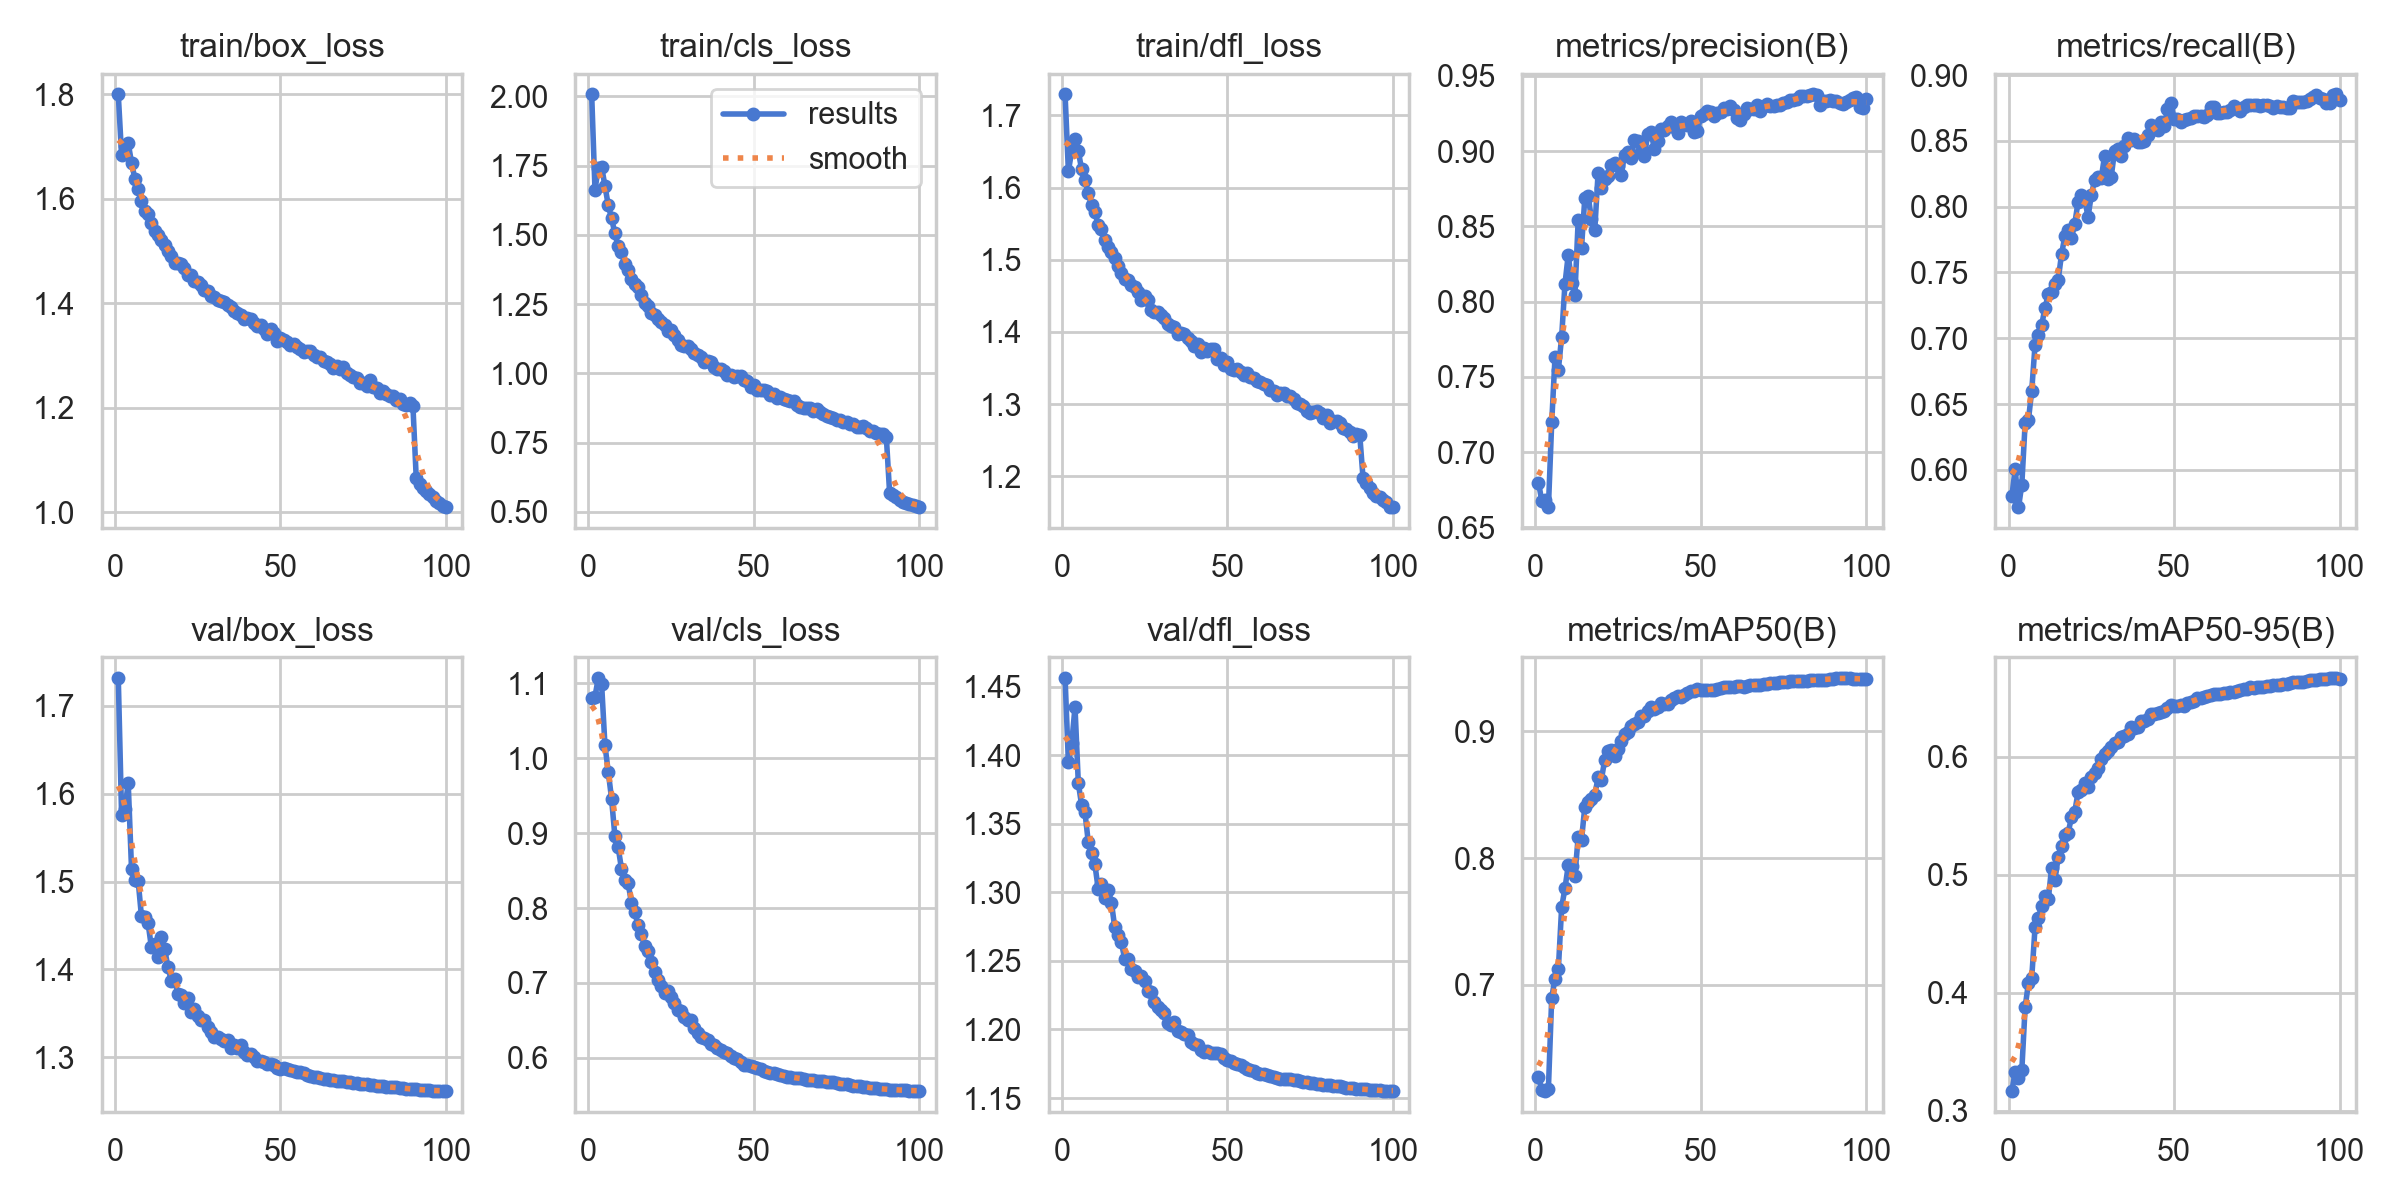


  F1-Confidence Curve


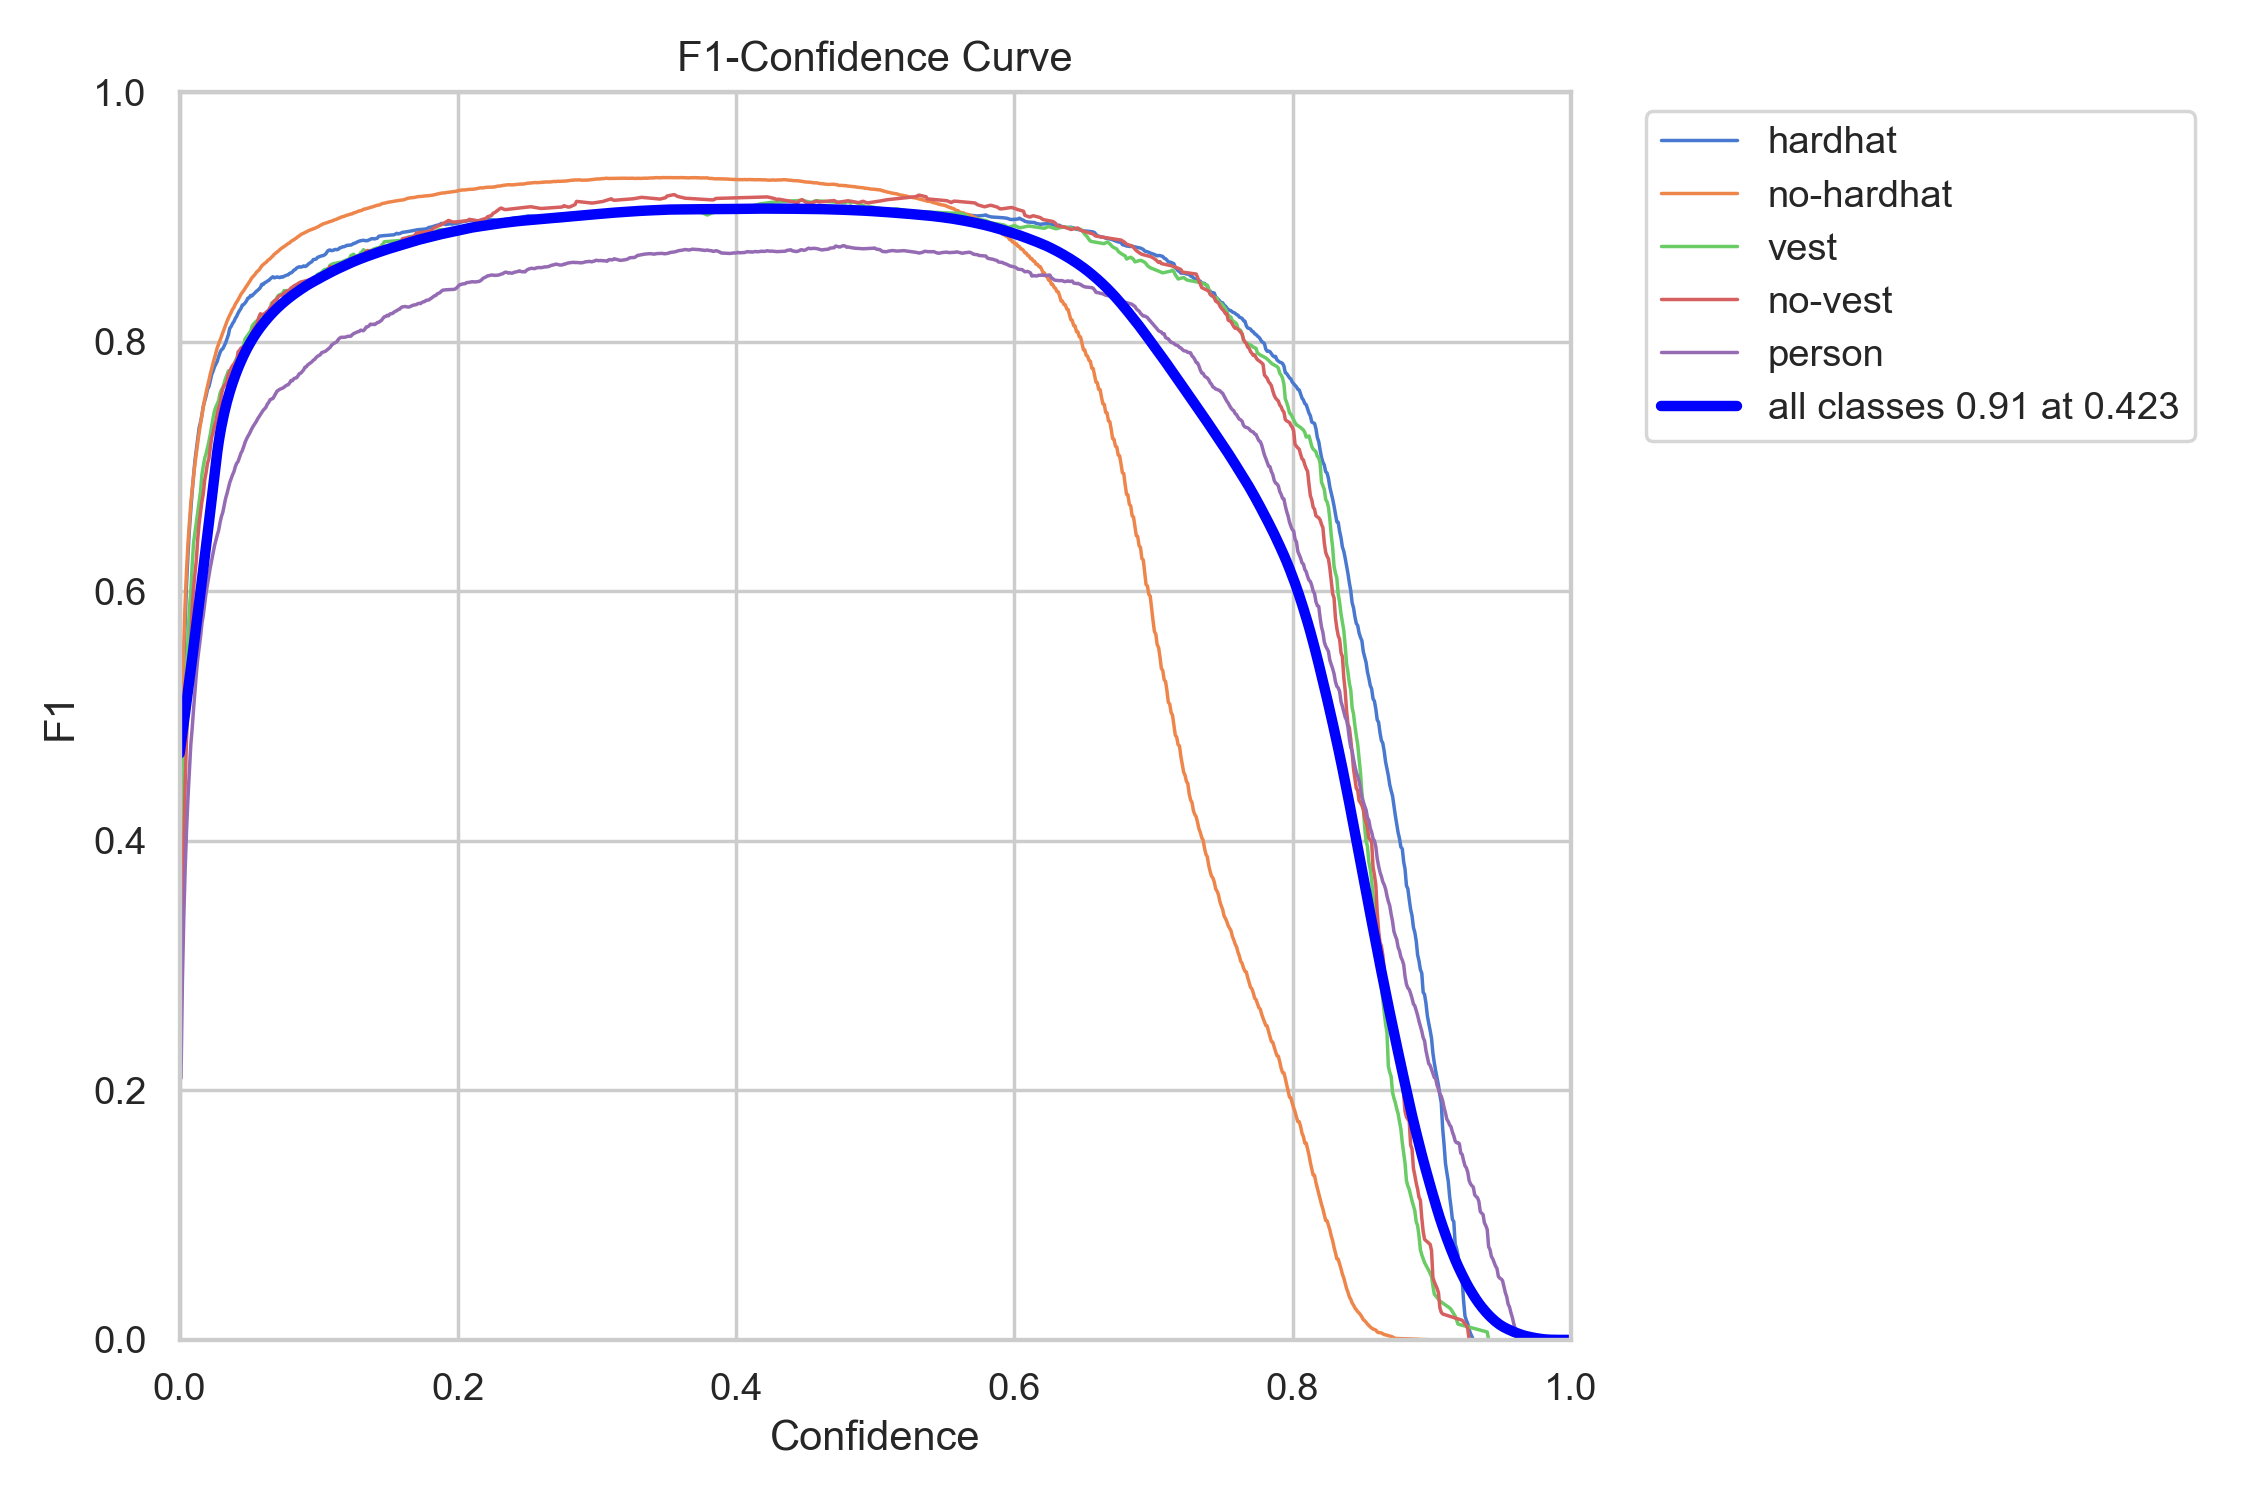


  Precision-Recall Curve


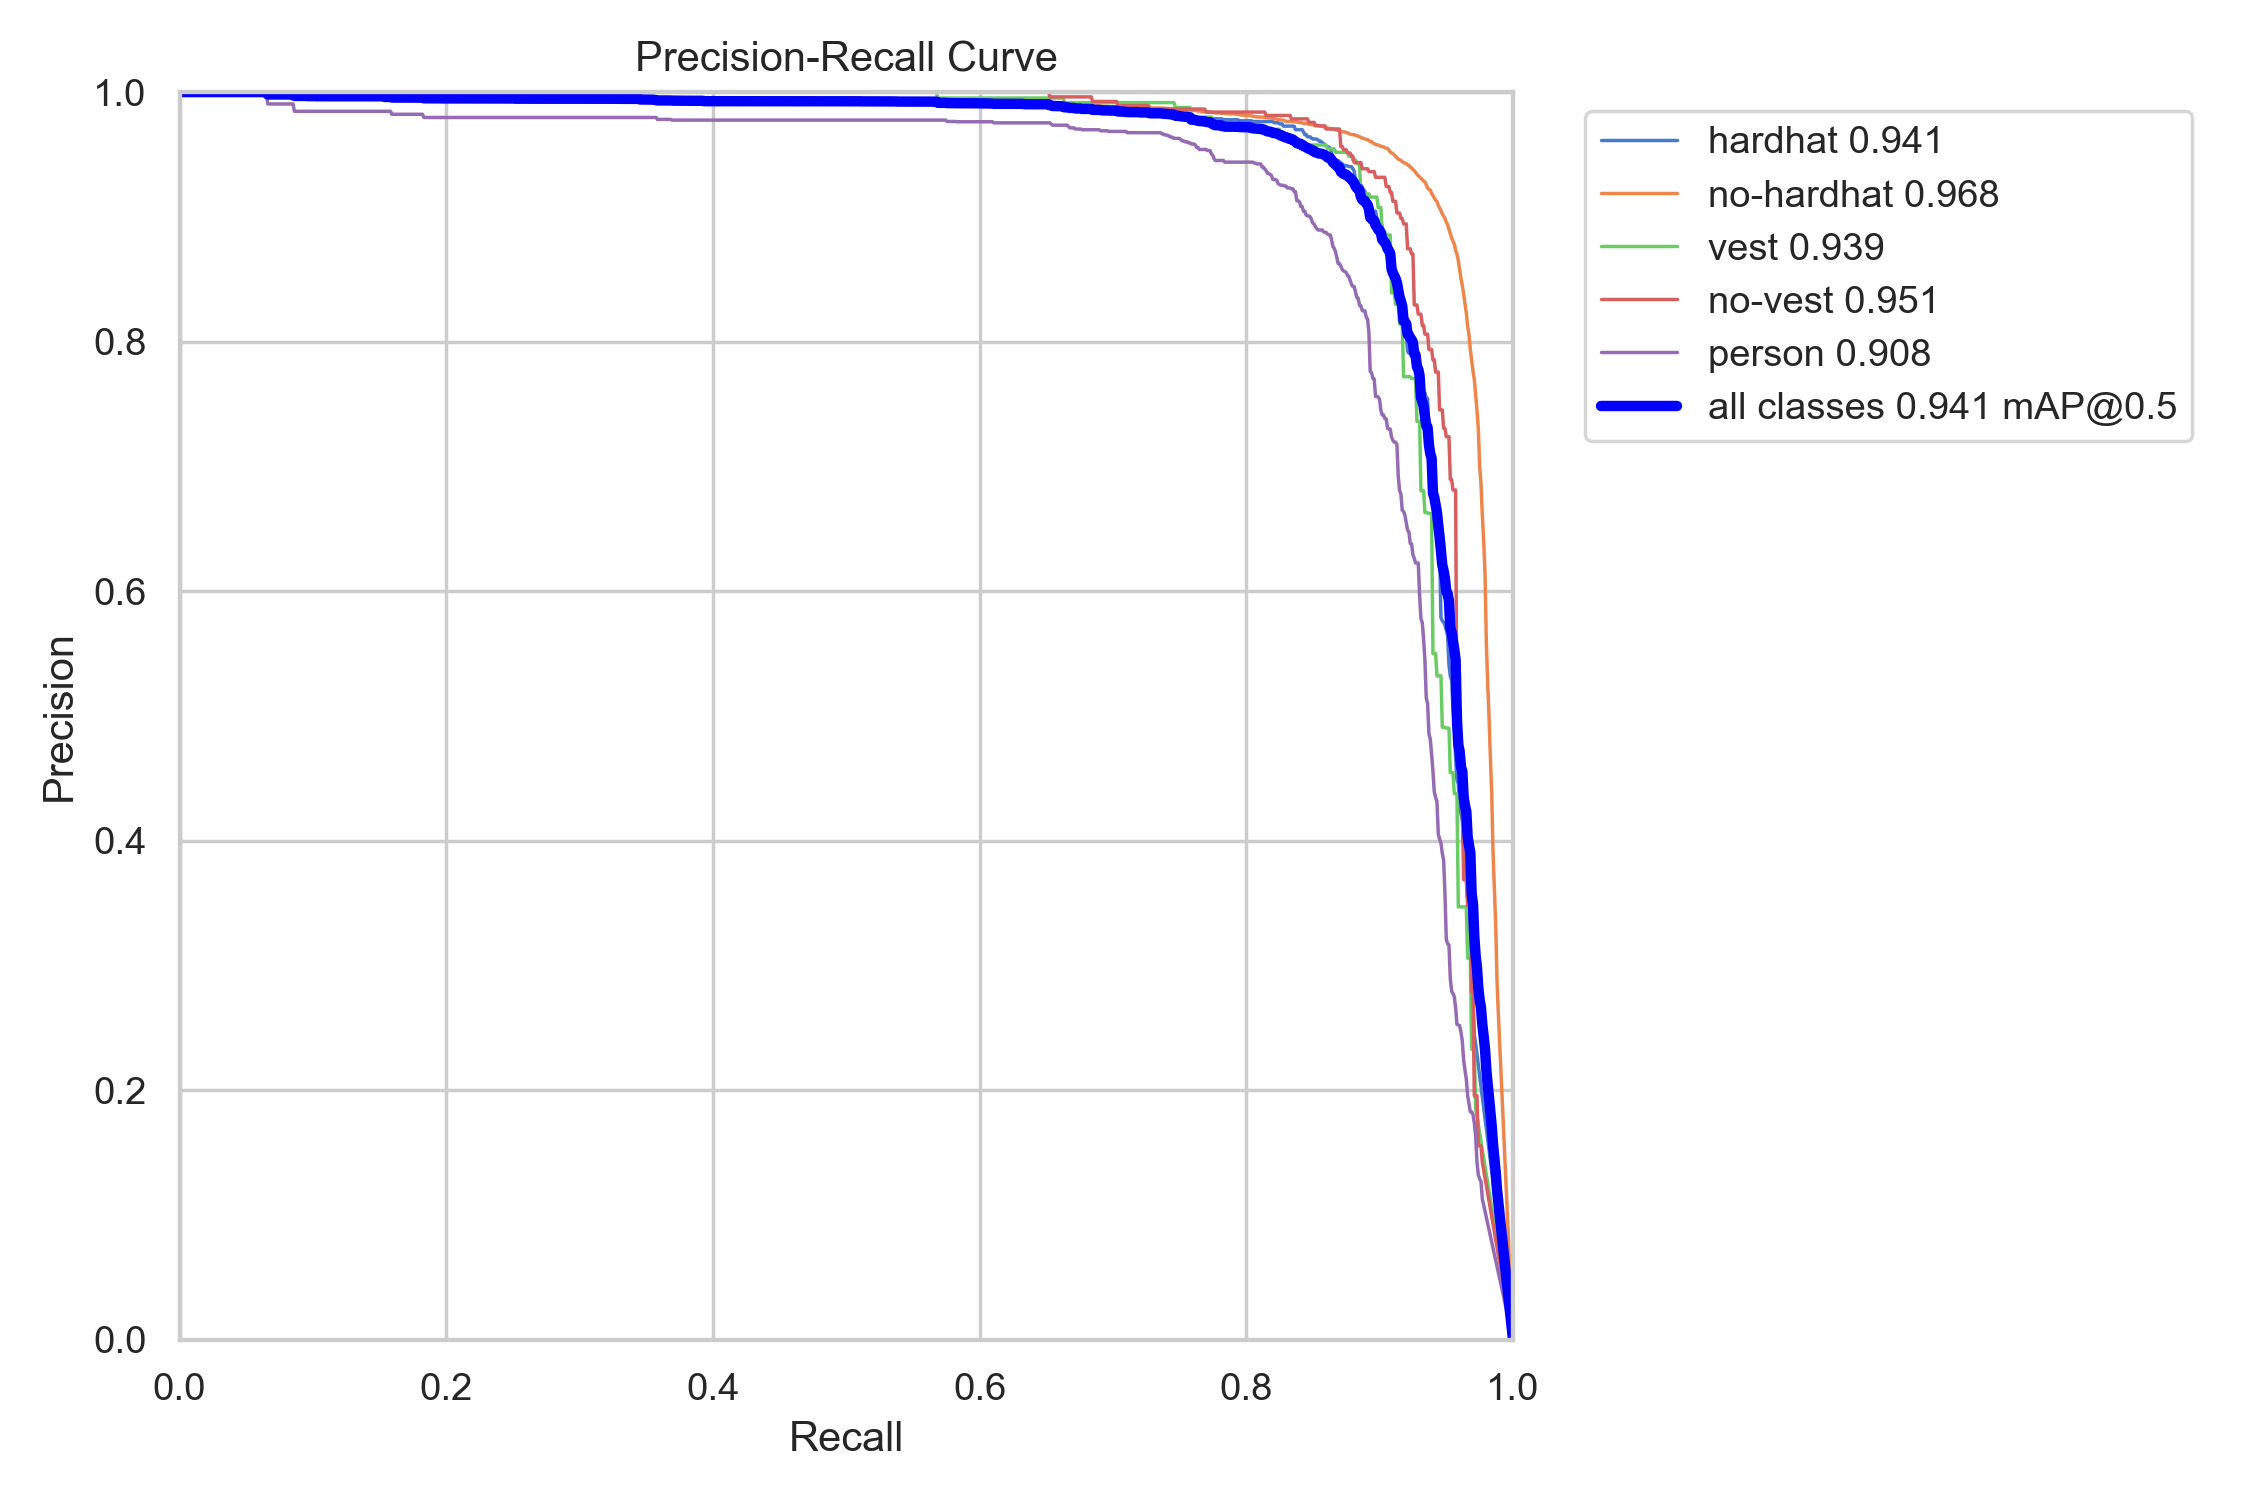


  Precision-Confidence Curve


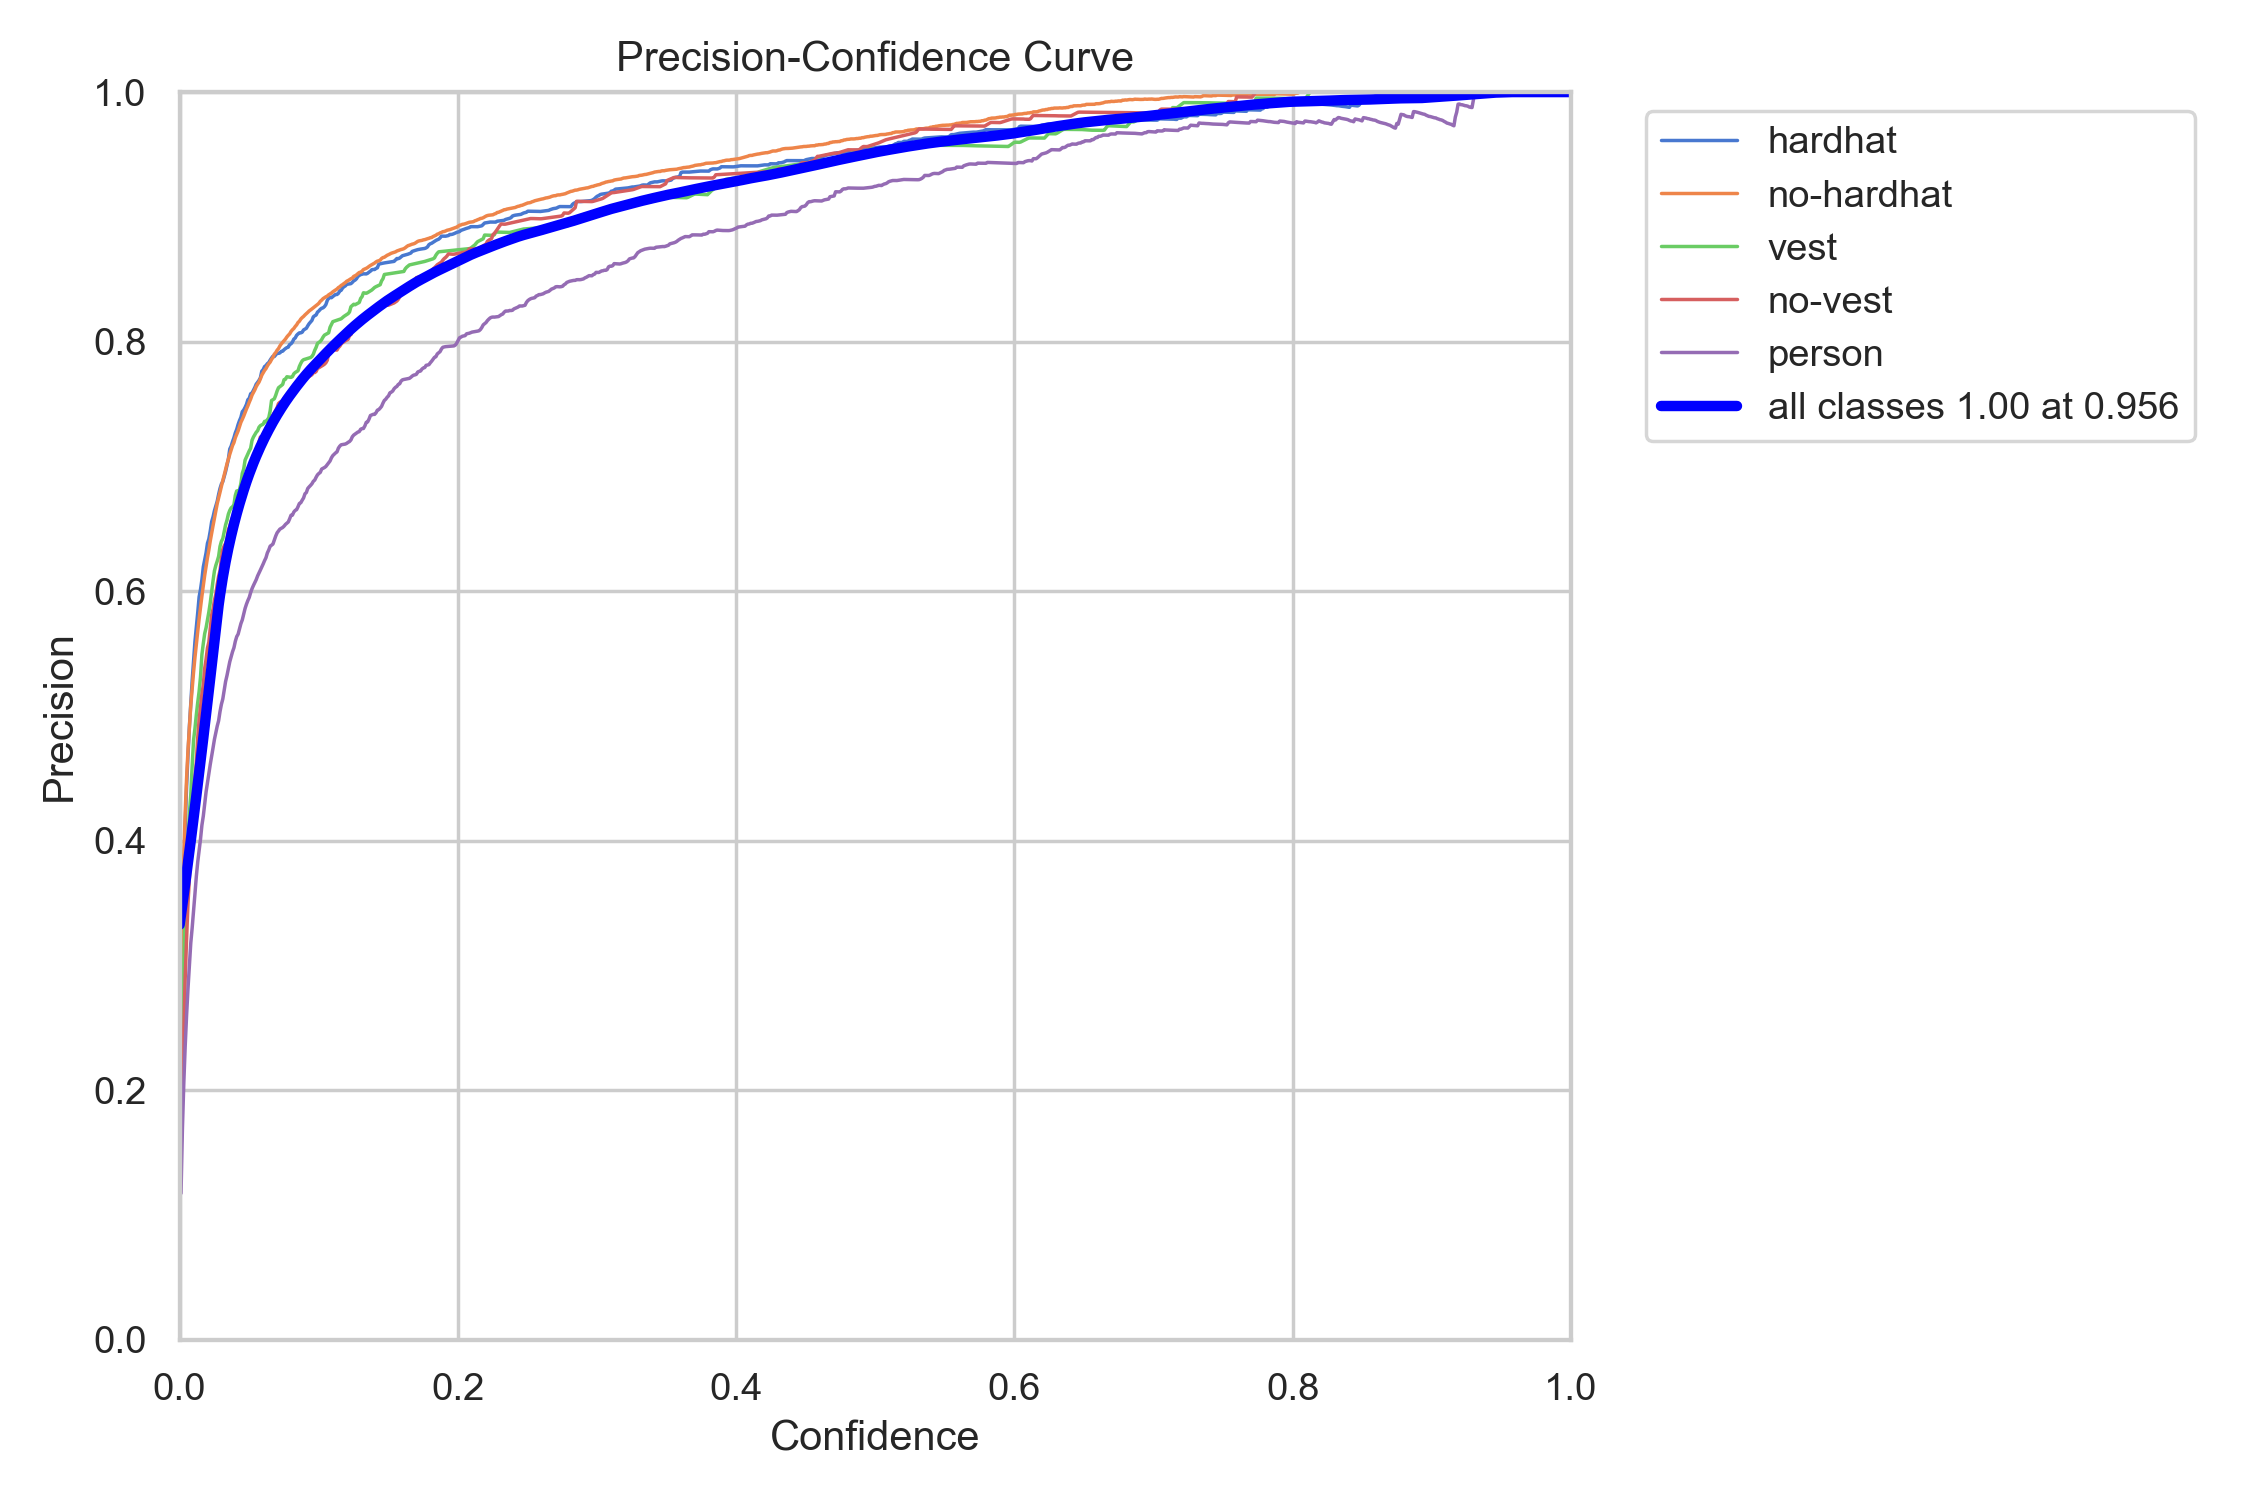


  Recall-Confidence Curve


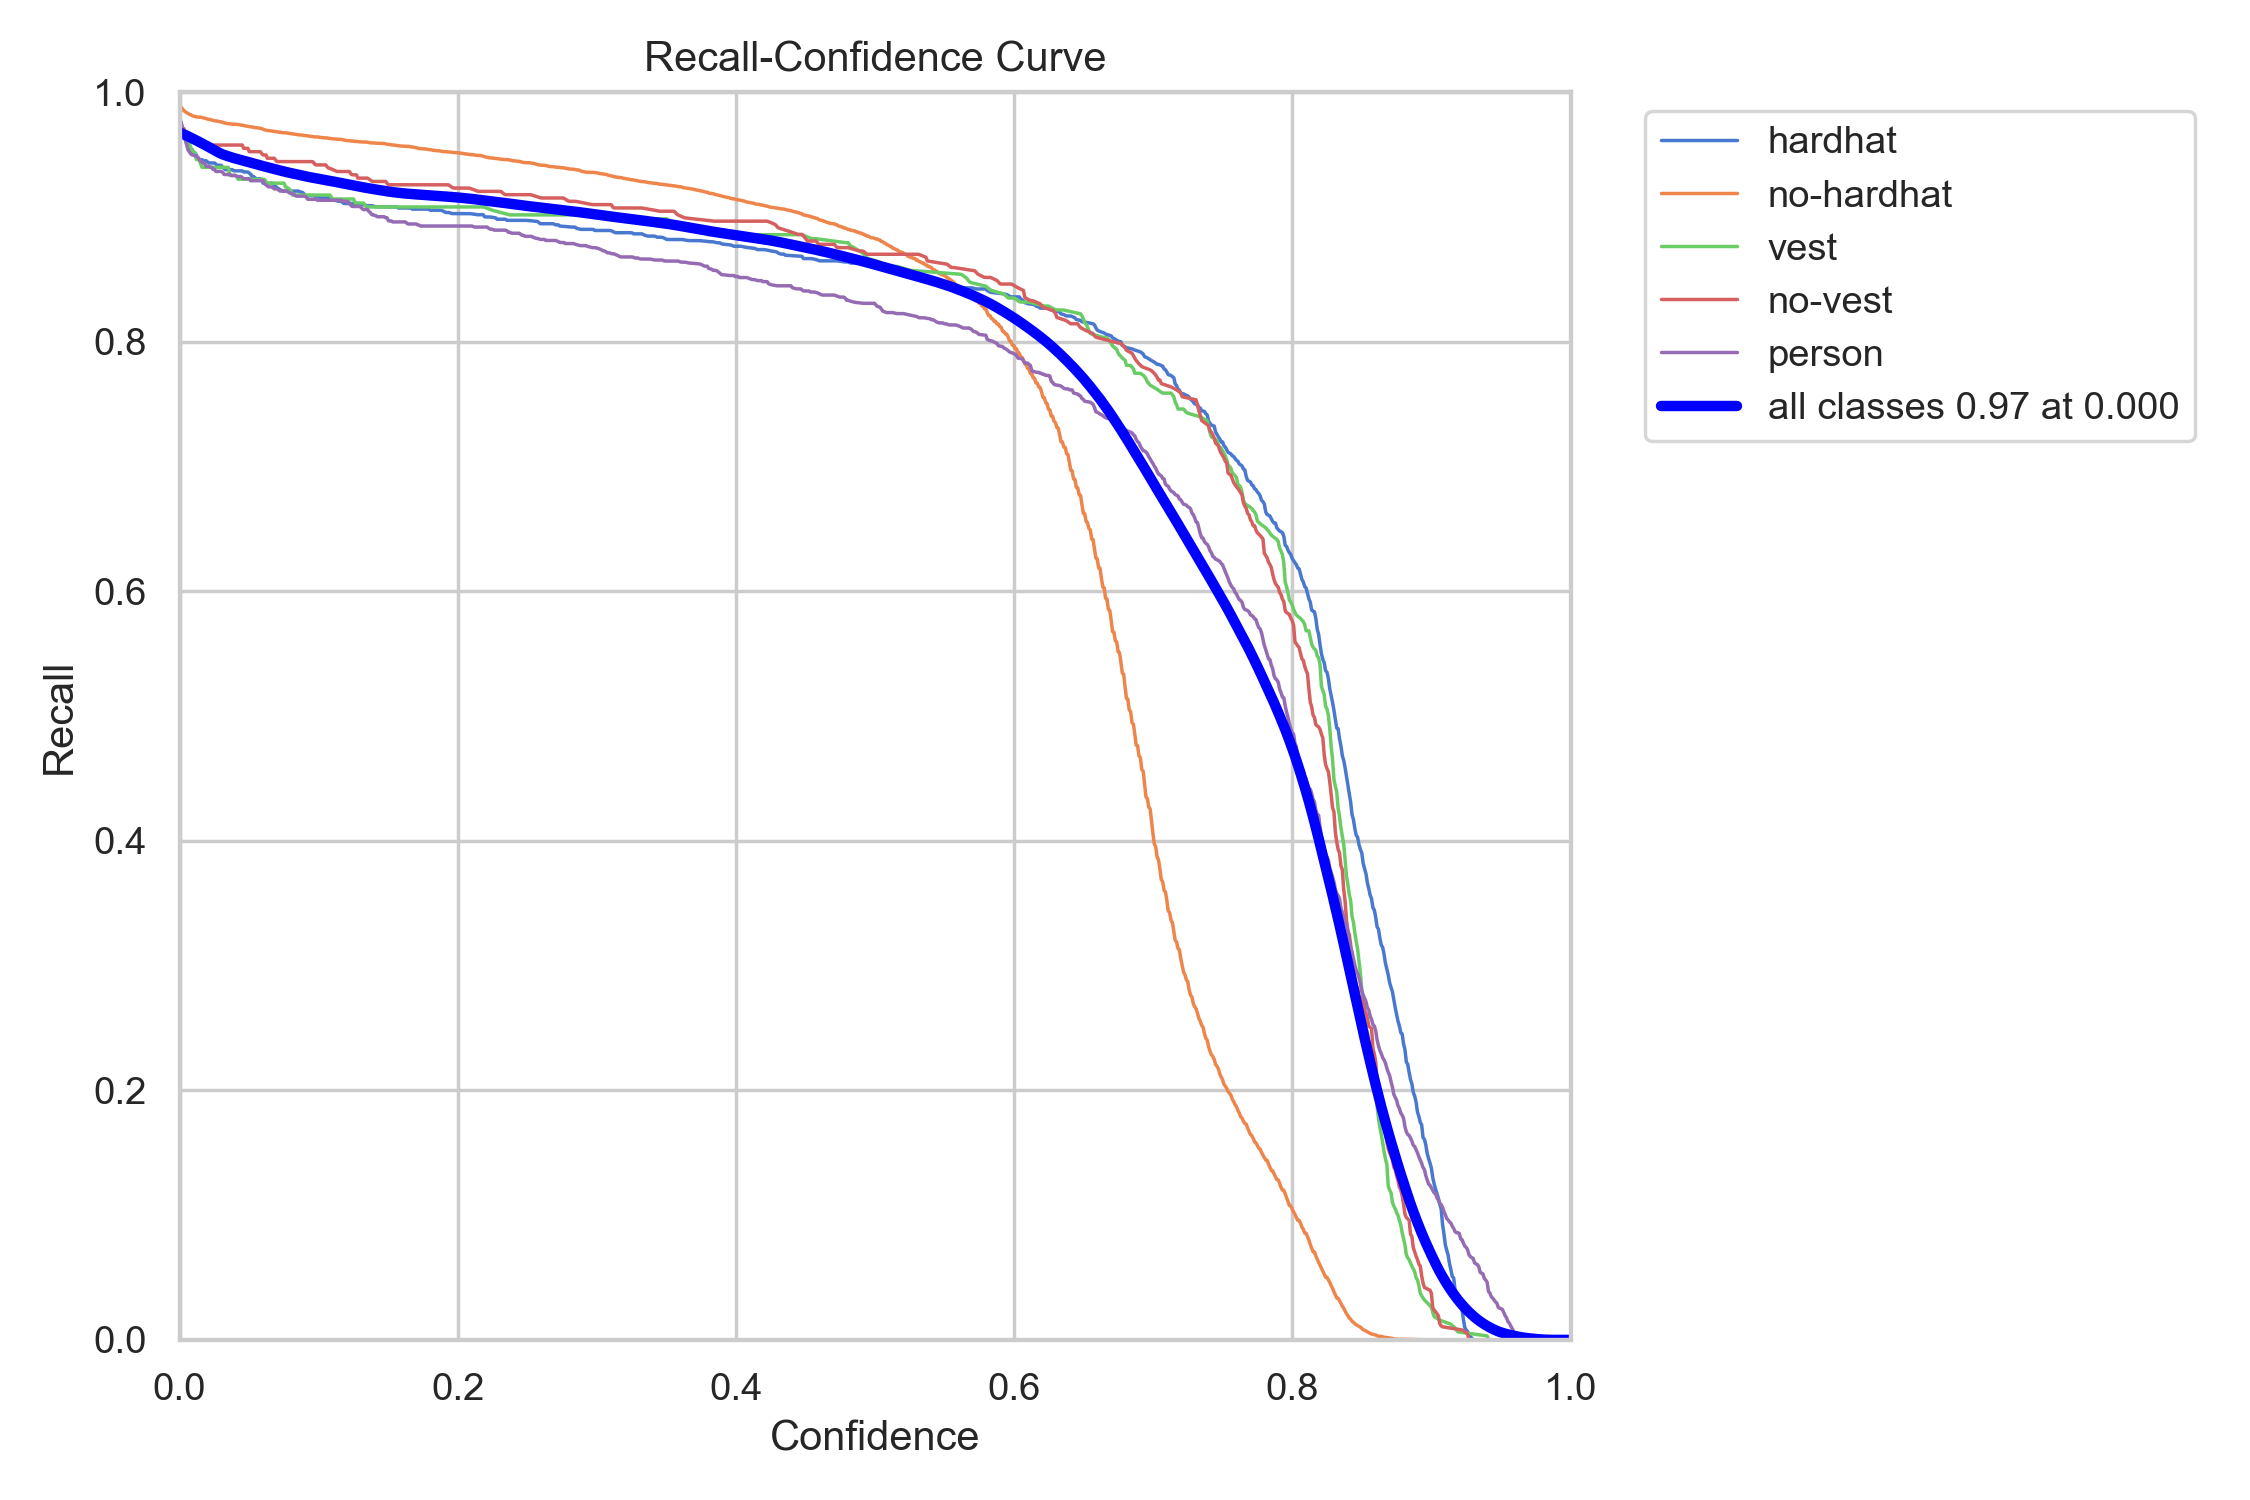


  Confusion Matrix


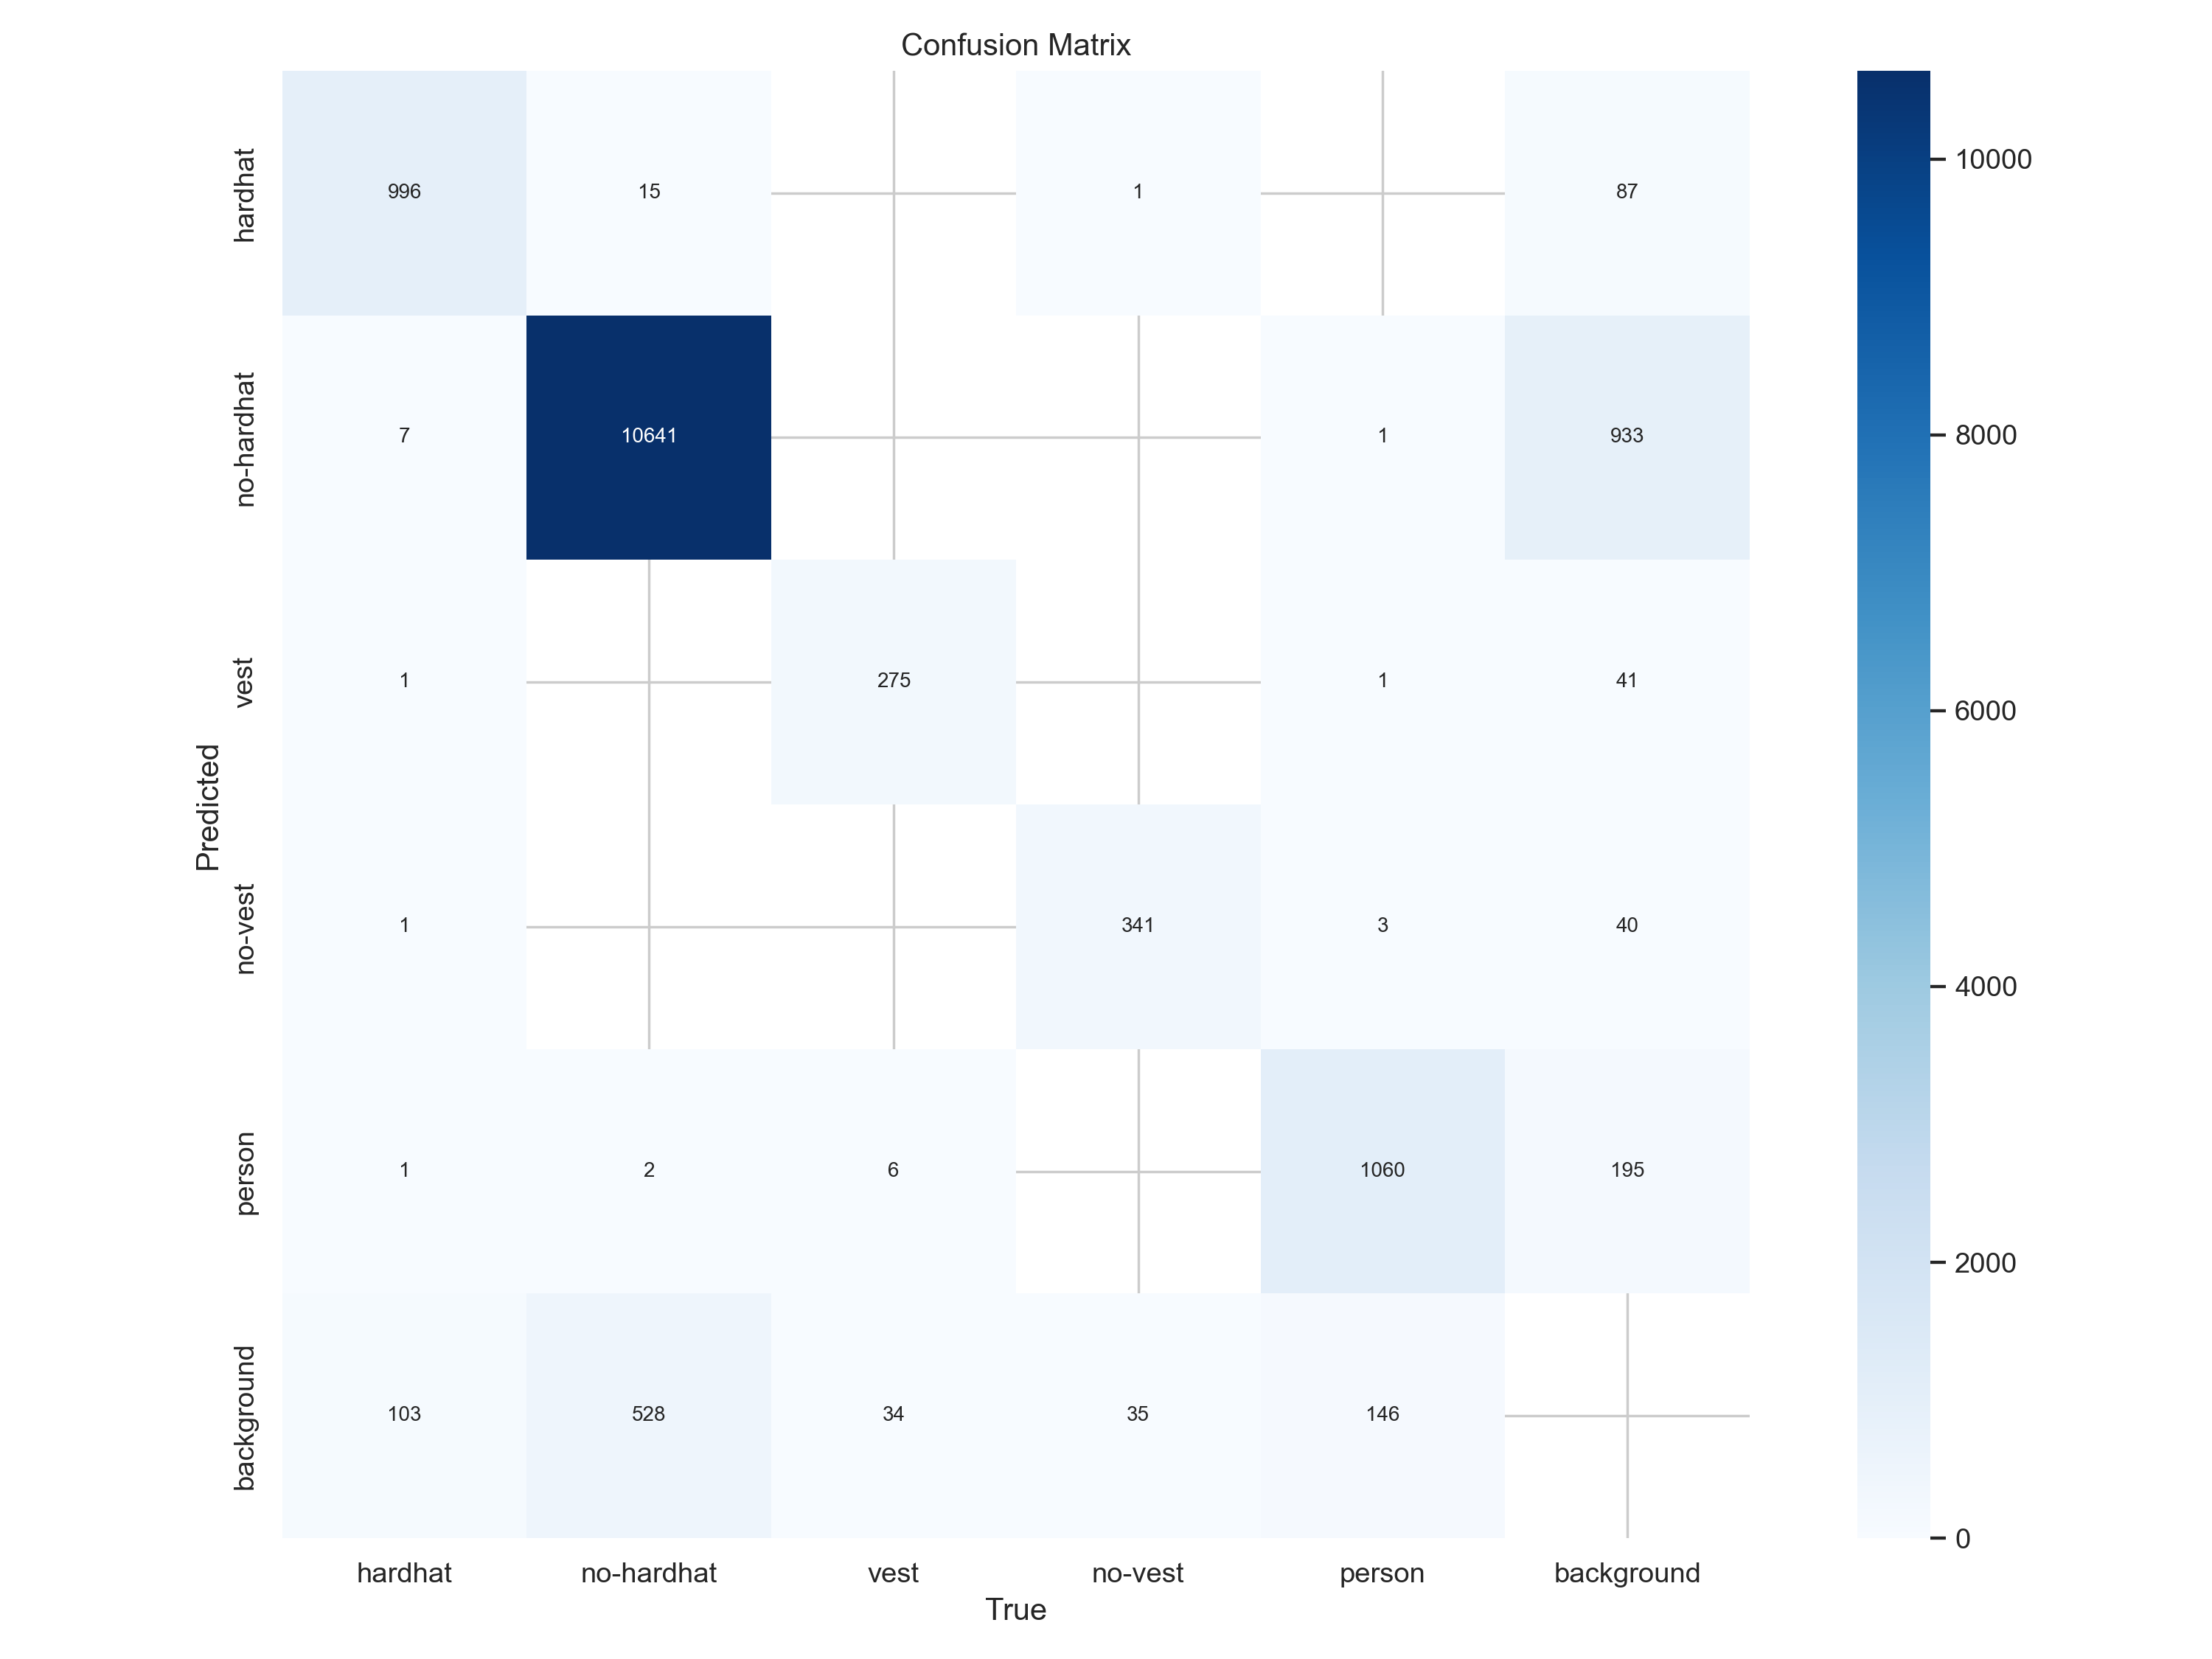


  Confusion Matrix (Normalized)


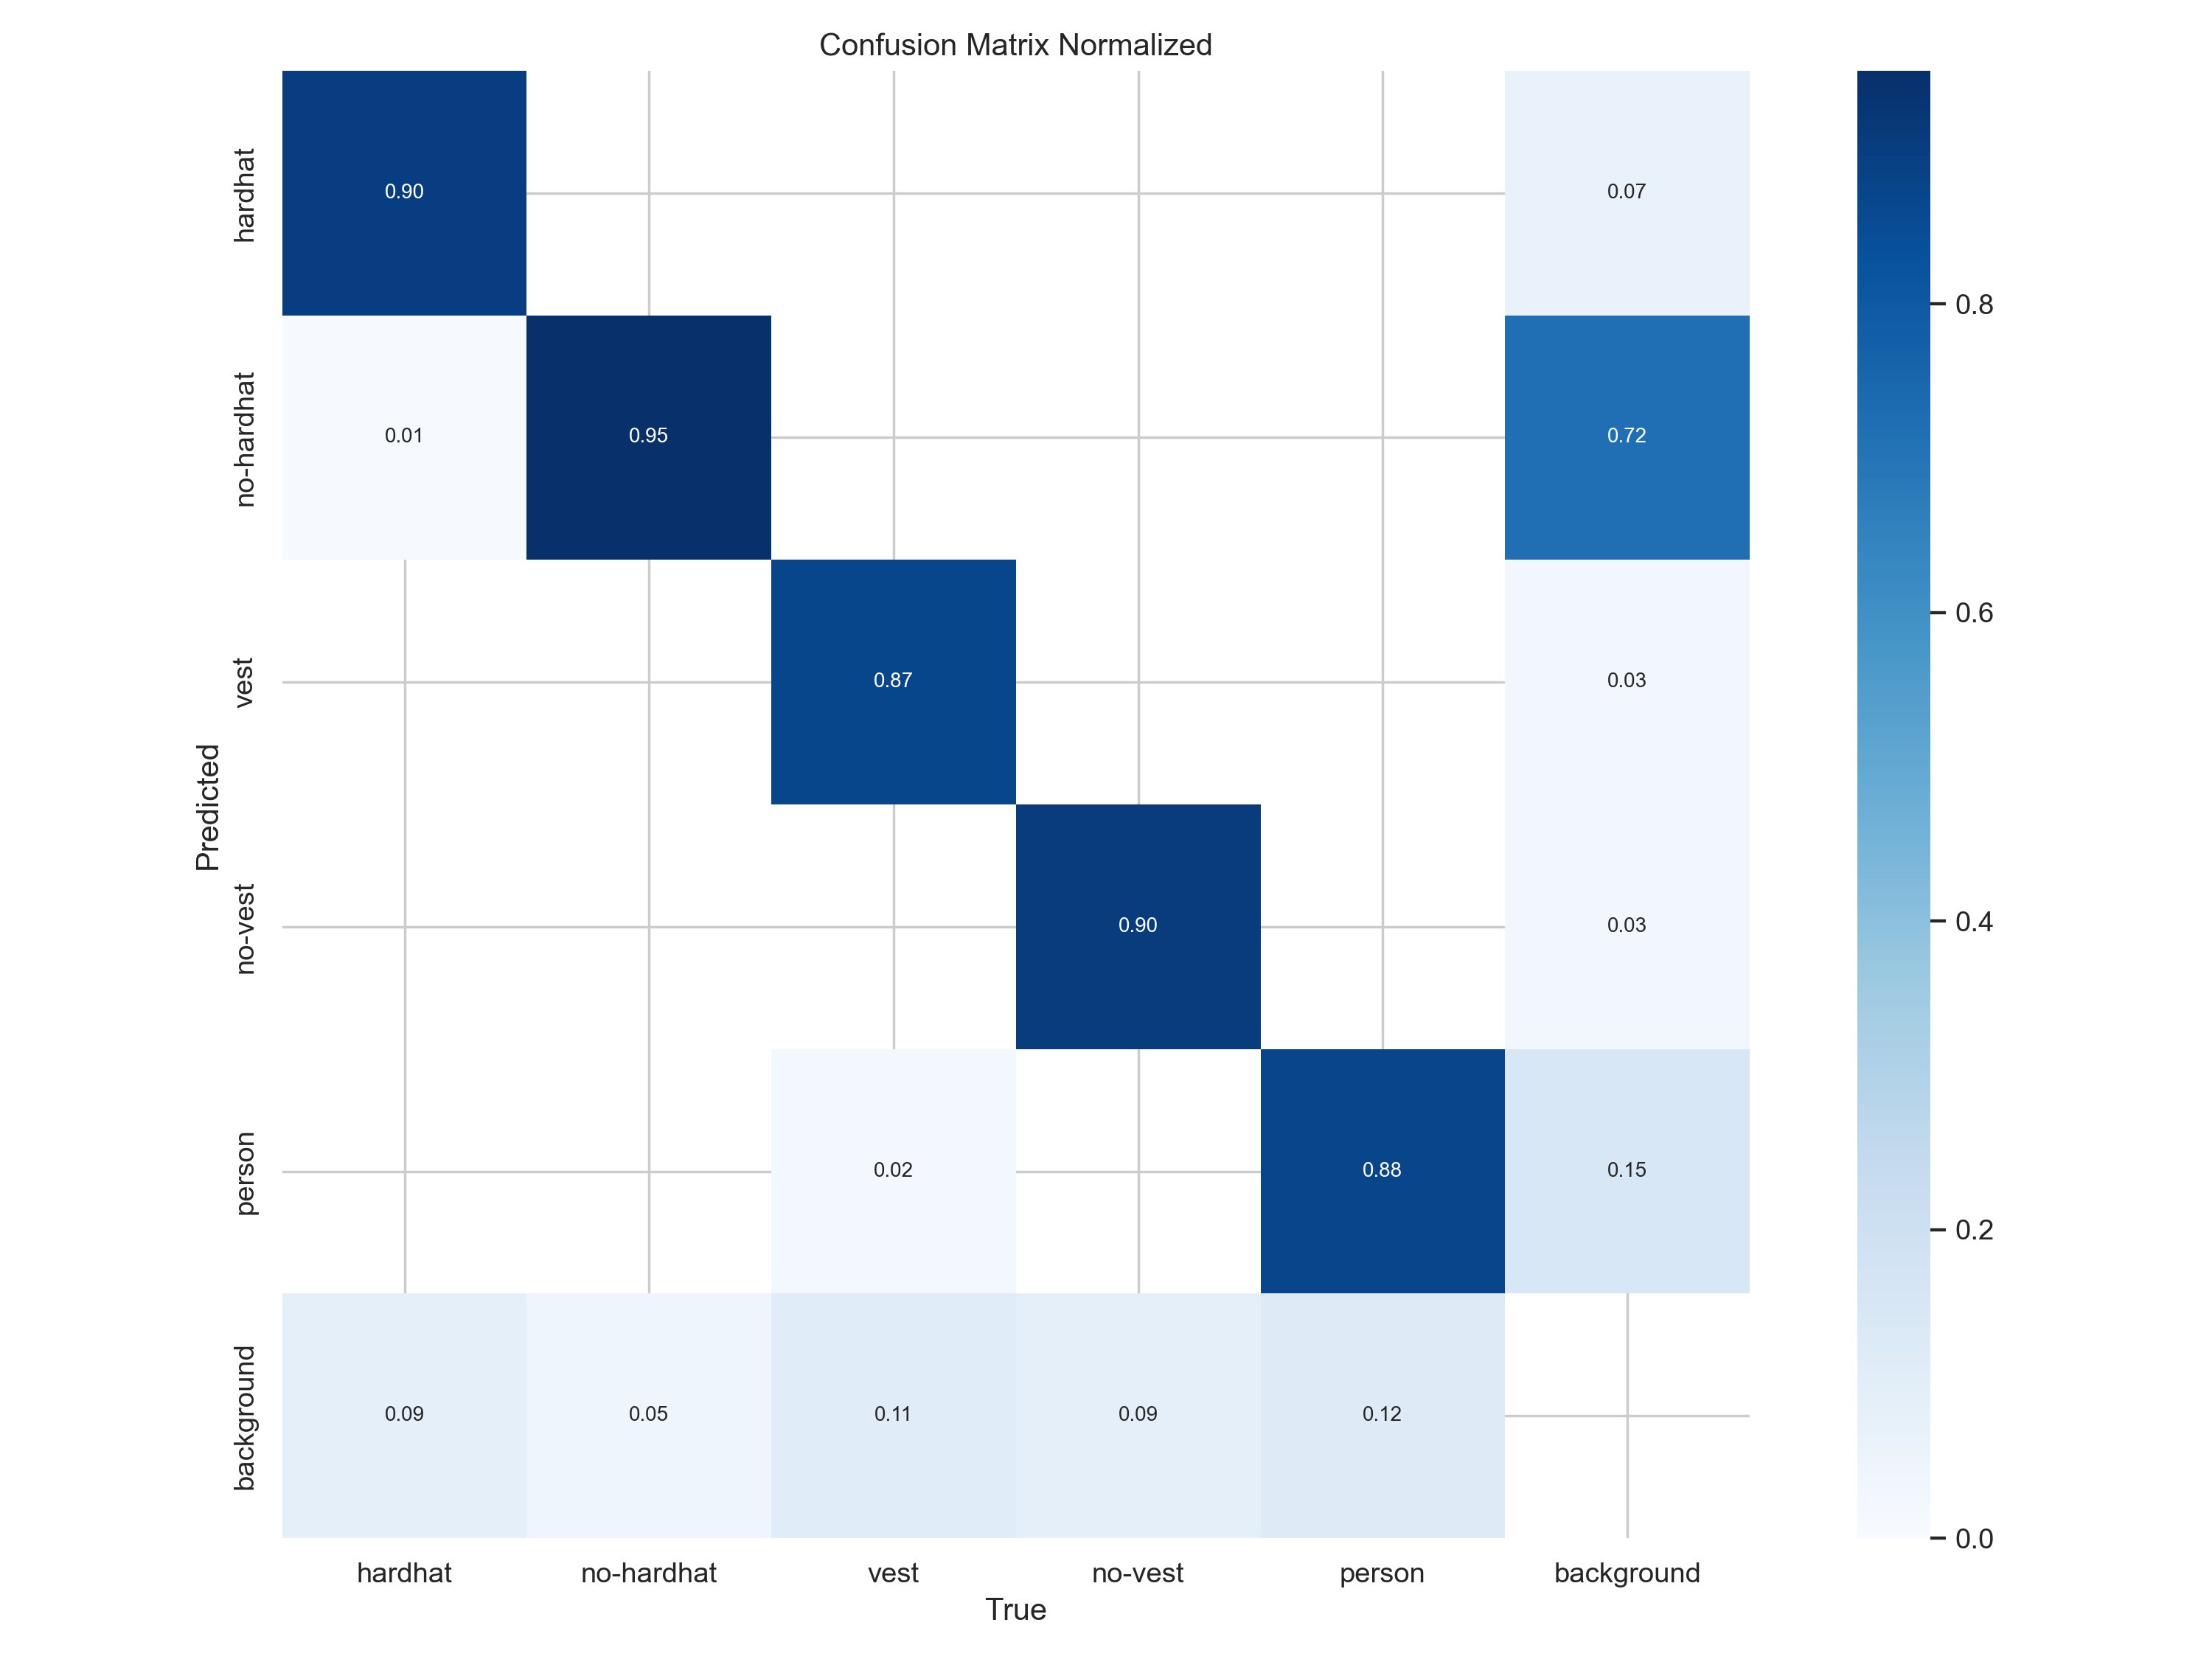

In [8]:
# ============================================================
# 4a. YOLO BUILT-IN PLOTS
# ============================================================
plot_files = [
    ('results.png',                     'Ultralytics Training Summary'),
    ('F1_curve.png',                    'F1-Confidence Curve'),
    ('PR_curve.png',                    'Precision-Recall Curve'),
    ('P_curve.png',                     'Precision-Confidence Curve'),
    ('R_curve.png',                     'Recall-Confidence Curve'),
    ('confusion_matrix.png',            'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalized)'),
]

for fname, title in plot_files:
    fpath = RUN_DIR / fname
    if fpath.exists():
        print(f'\n{"=" * 60}')
        print(f'  {title}')
        print(f'{"=" * 60}')
        display(IPImage(filename=str(fpath), width=900))
    else:
        print(f'  {fname} not found — skipping')


--- val_batch0_labels ---
Ground Truth:


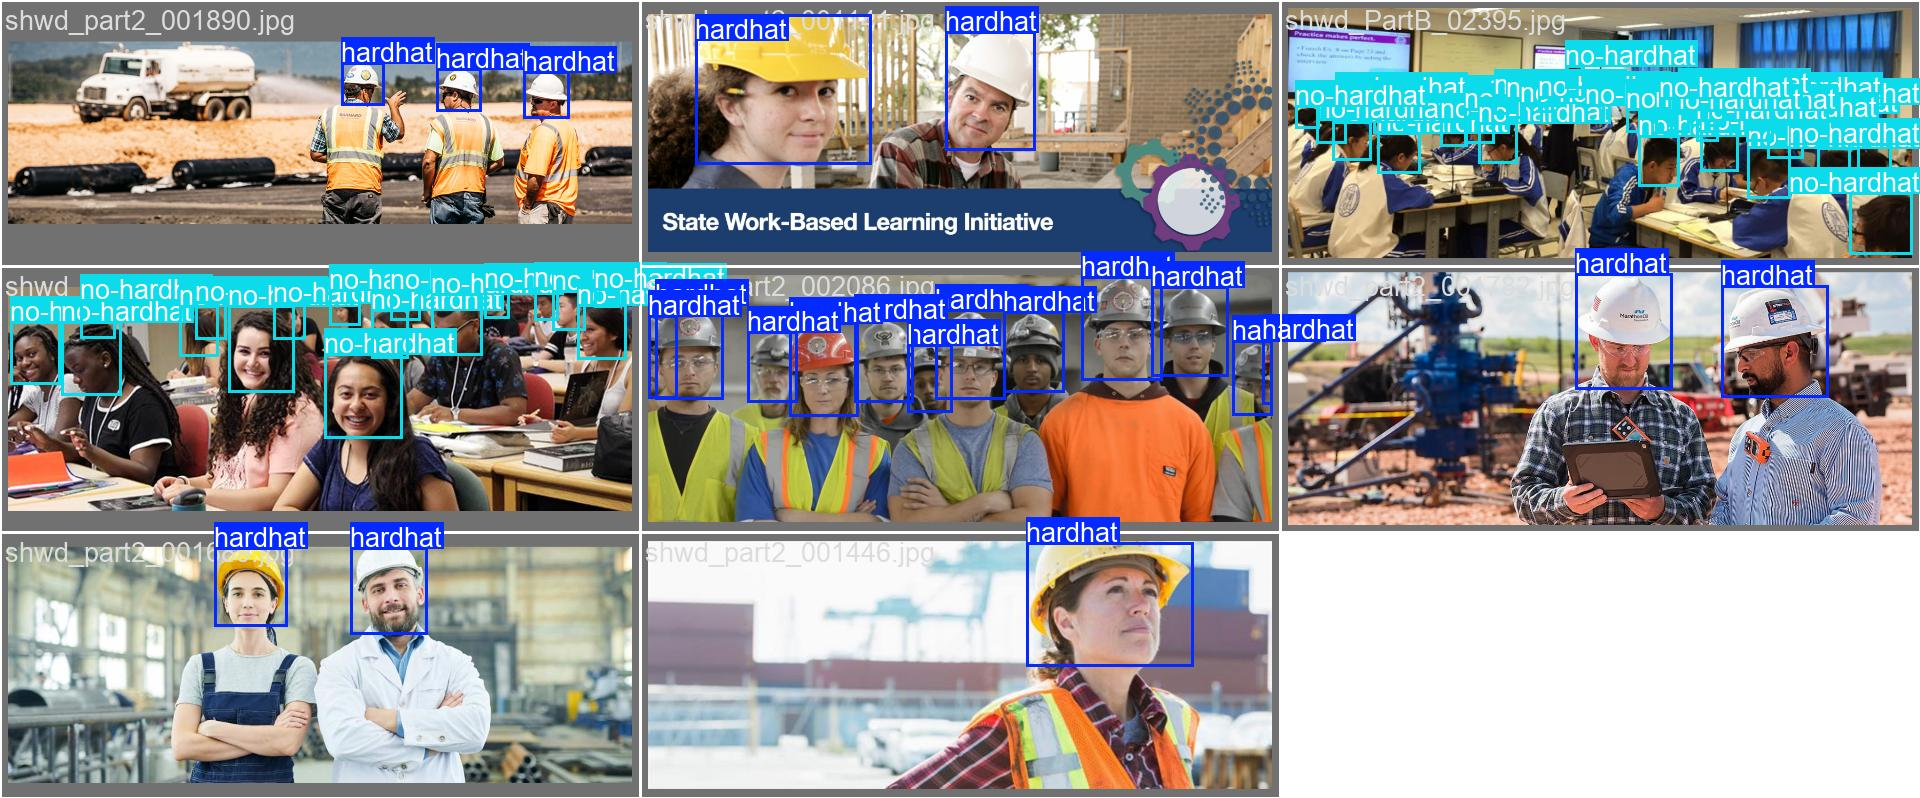

Predictions:


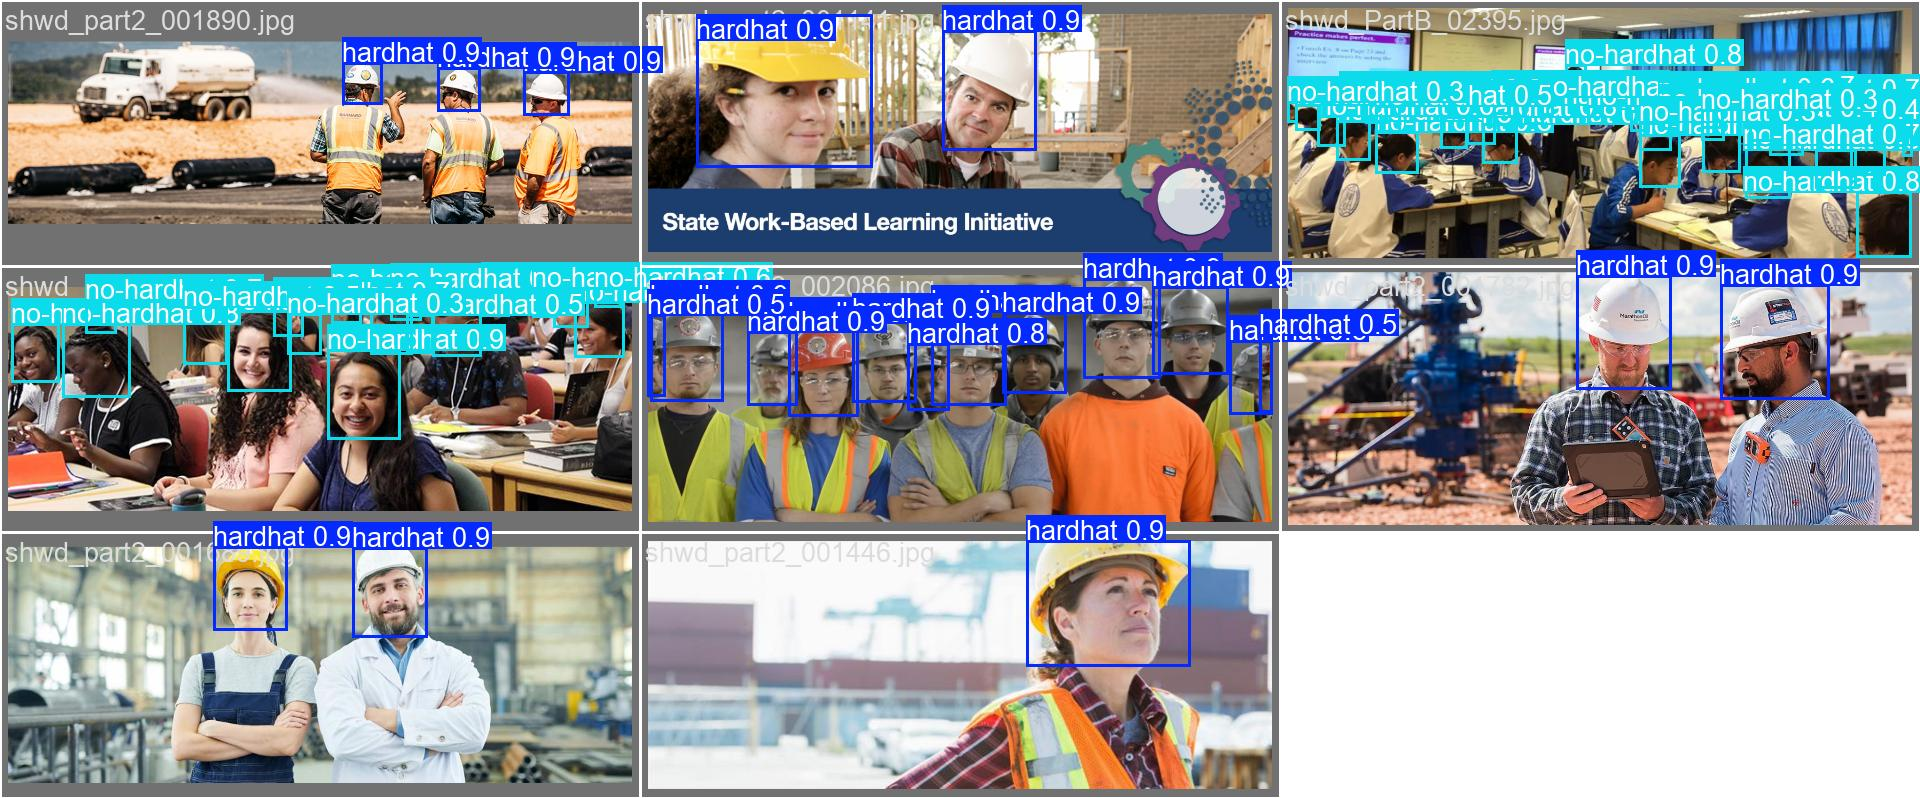


--- val_batch1_labels ---
Ground Truth:


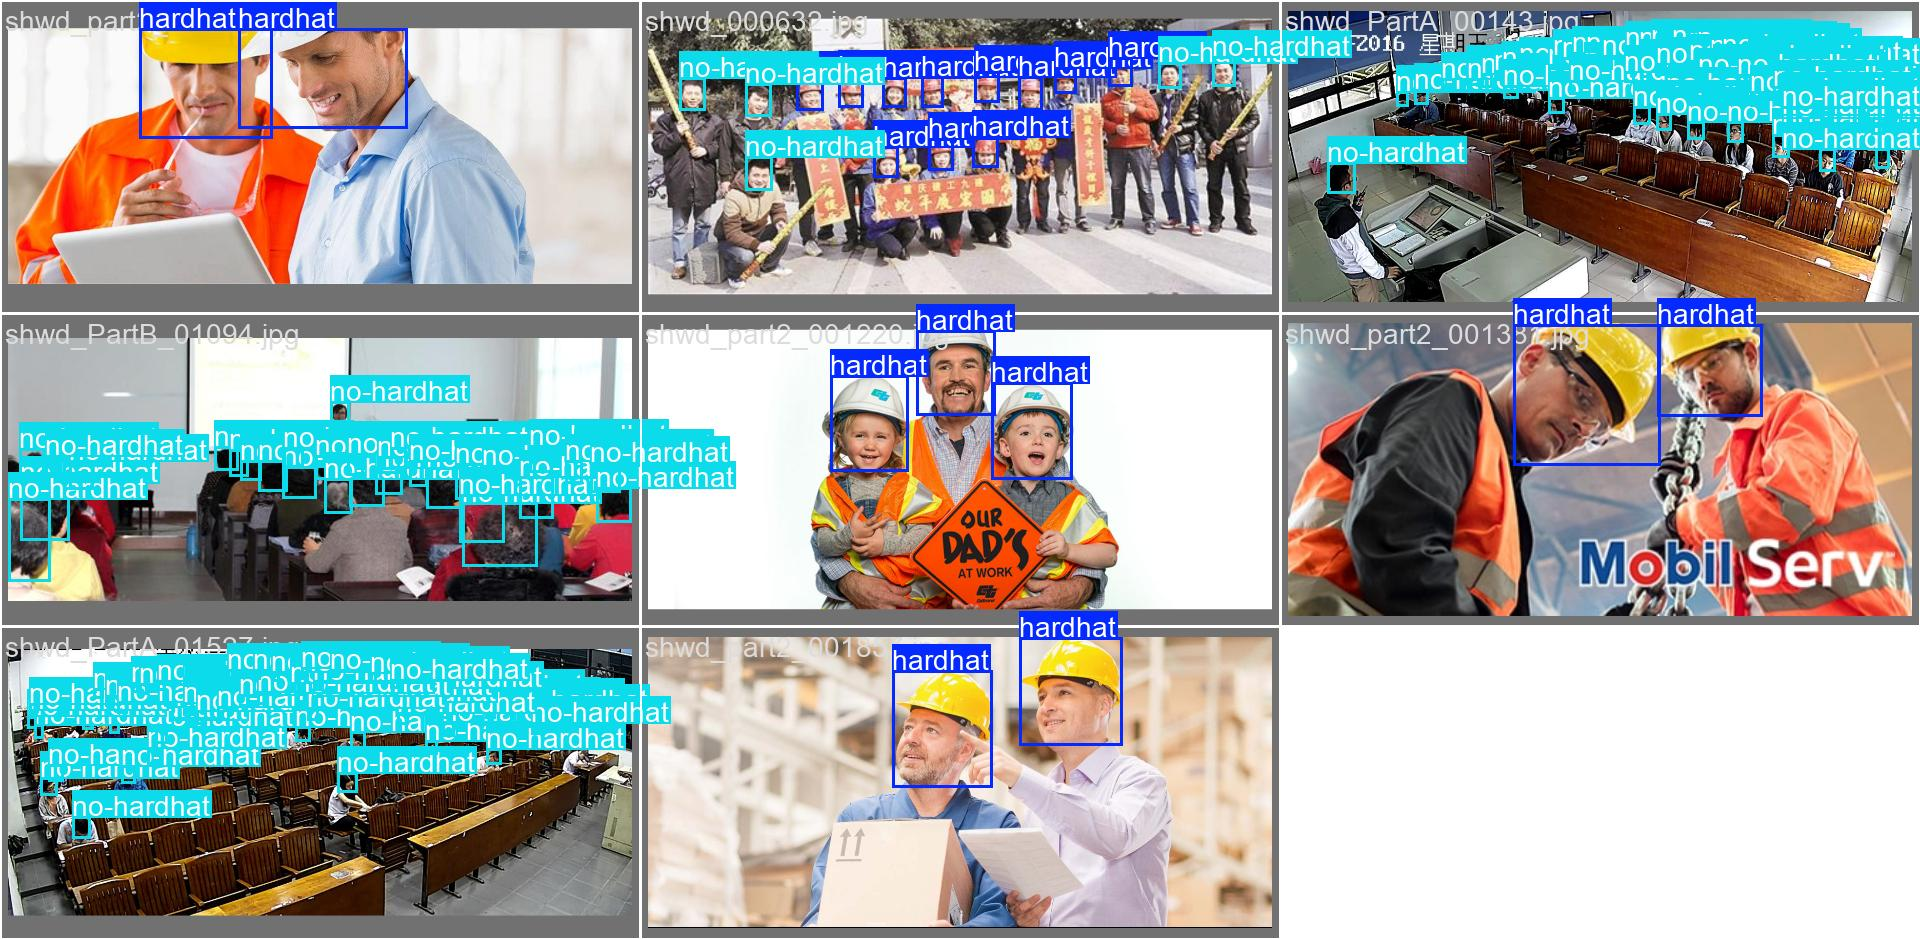

Predictions:


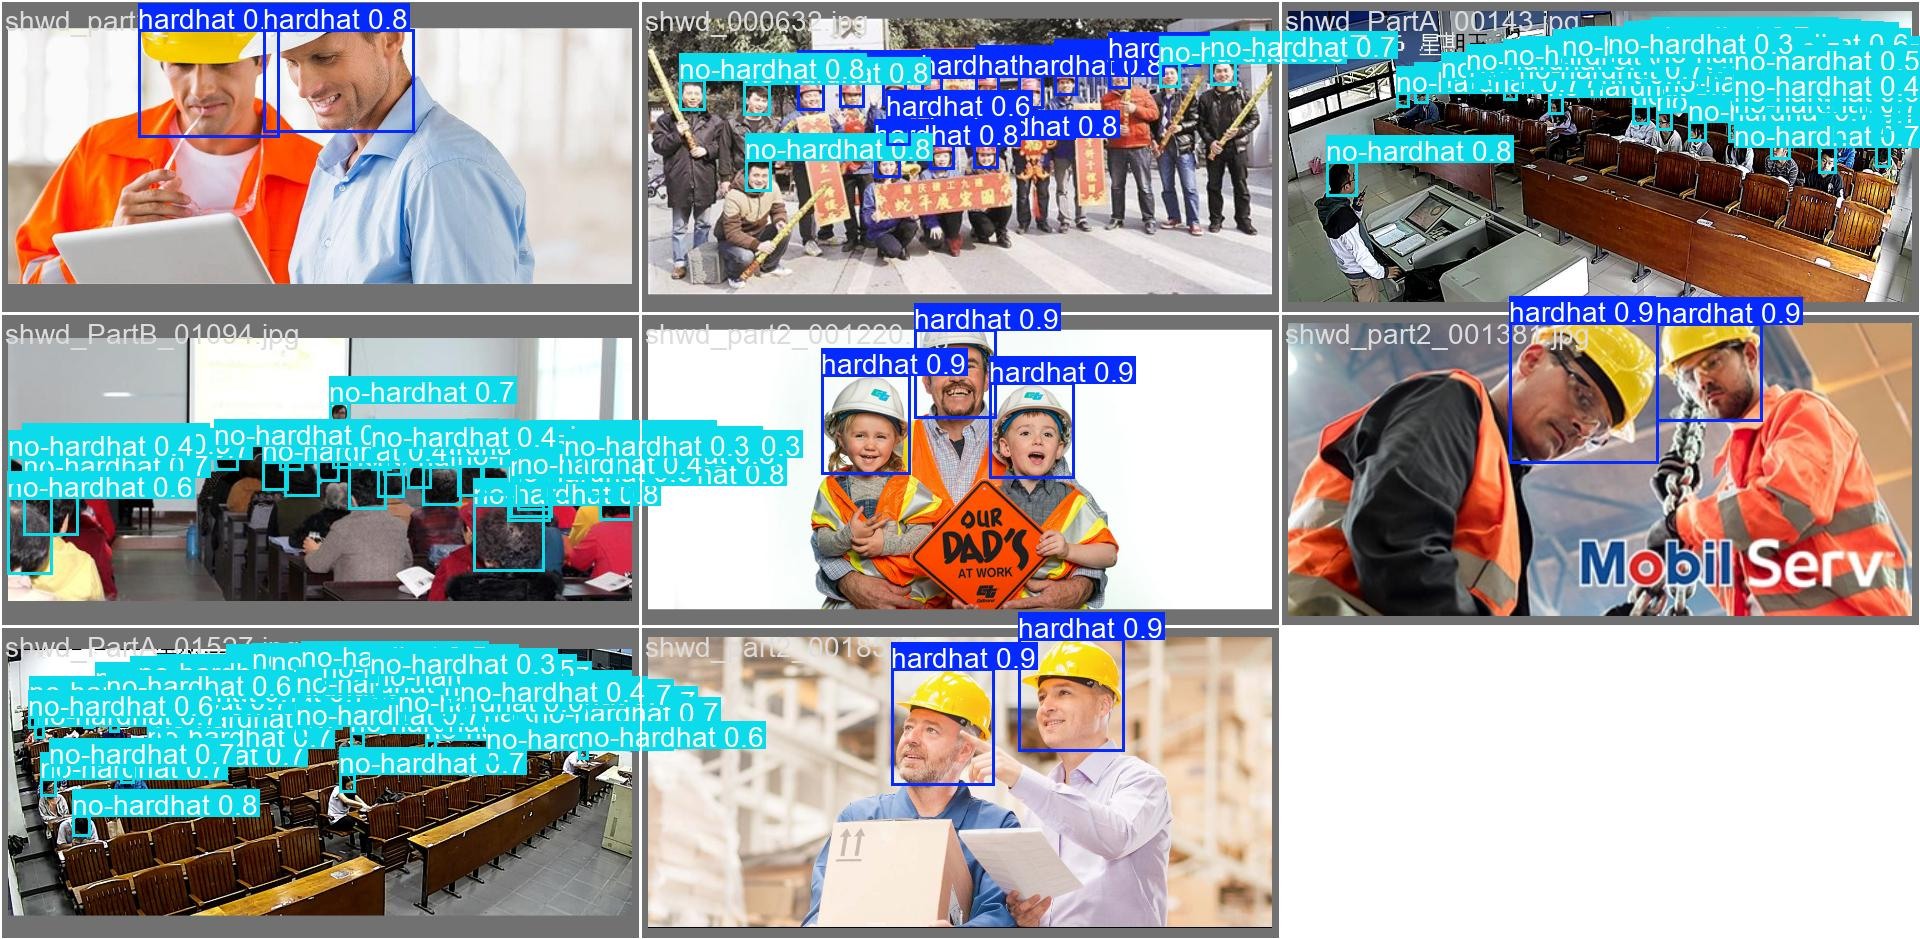


--- val_batch2_labels ---
Ground Truth:


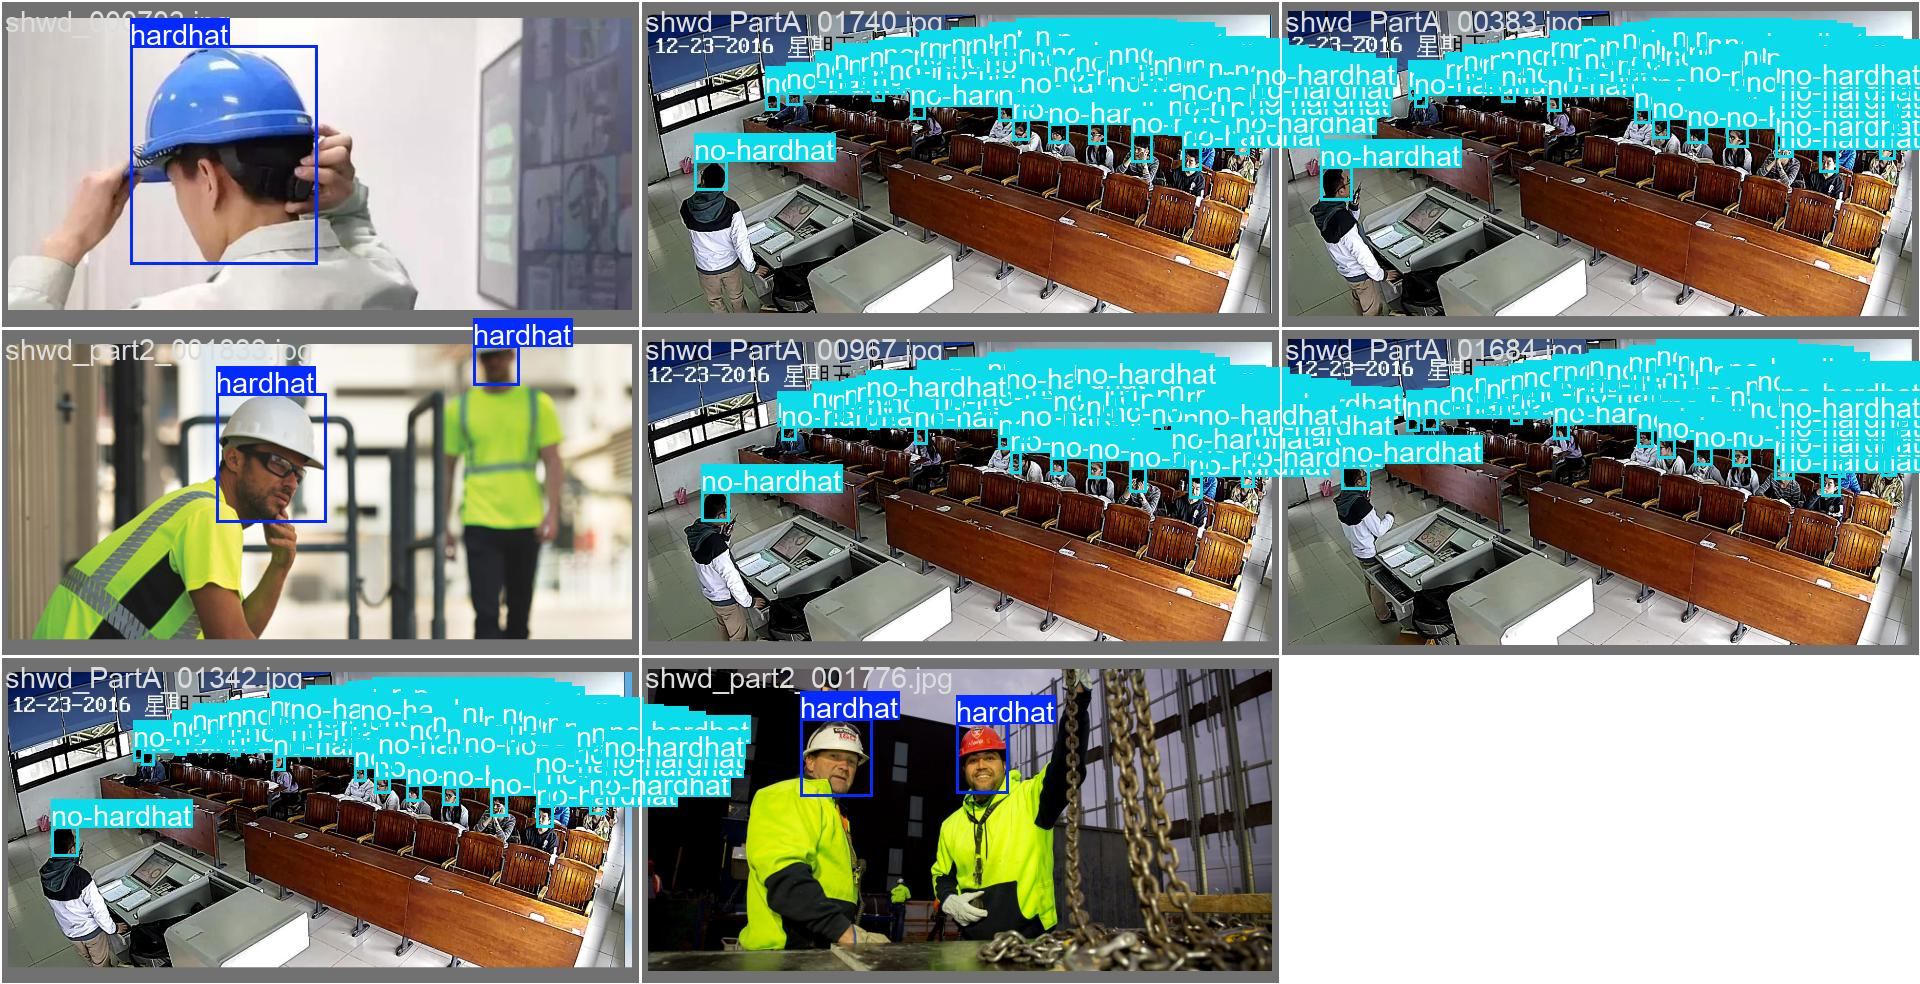

Predictions:


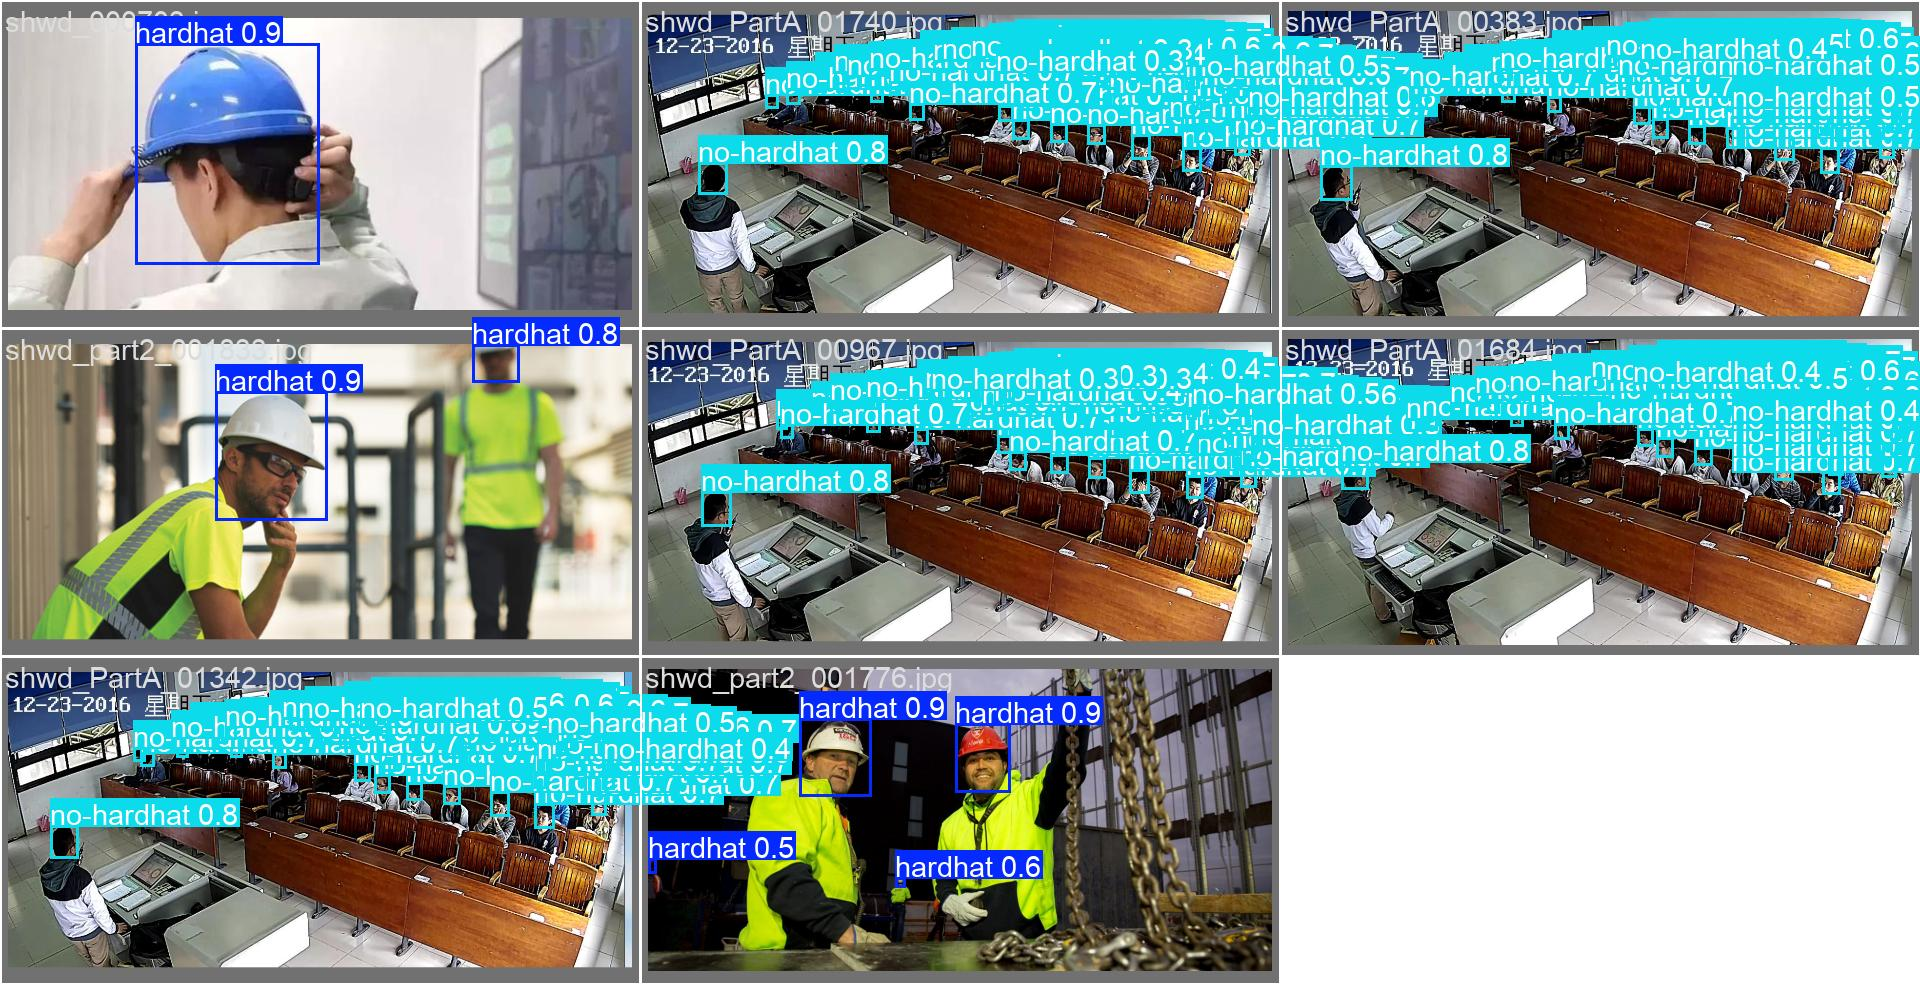

In [9]:
# ============================================================
# 4b. SAMPLE PREDICTIONS (val batch — ground truth vs preds)
# ============================================================
pred_files = [
    ('val_batch0_labels.jpg', 'val_batch0_pred.jpg'),
    ('val_batch1_labels.jpg', 'val_batch1_pred.jpg'),
    ('val_batch2_labels.jpg', 'val_batch2_pred.jpg'),
]

for labels_f, preds_f in pred_files:
    labels_path = RUN_DIR / labels_f
    preds_path  = RUN_DIR / preds_f
    if labels_path.exists() and preds_path.exists():
        print(f'\n--- {labels_f.replace(".jpg", "")} ---')
        print('Ground Truth:')
        display(IPImage(filename=str(labels_path), width=800))
        print('Predictions:')
        display(IPImage(filename=str(preds_path), width=800))
    else:
        print(f'  {labels_f} / {preds_f} not found — skipping')

---
## 5. Per-Class Checkpoint Eval (AP50 at key epochs + best)

In [10]:
# ============================================================
# 5. PER-CLASS CHECKPOINT EVAL
# Runs model.val() on saved checkpoints for per-class AP50.
# ============================================================

def eval_checkpoint(weights_path, label):
    """Run val on a checkpoint and return per-class metrics dict, or None if missing."""
    if not weights_path.exists():
        print(f'  [{label}] {weights_path.name} not found — skipping')
        return None

    ckpt_model = YOLO(str(weights_path))
    m = ckpt_model.val(
        data    = str(DATA_YAML),
        imgsz   = cfg['imgsz'],
        half    = cfg['half'],
        device  = 0,
        split   = 'val',
        verbose = False,
    )

    row = {
        'checkpoint': label,
        'map50':      float(m.box.map50),
        'map5095':    float(m.box.map),
    }
    for i, cls in enumerate(CLASS_NAMES):
        row[f'ap50_{cls}'] = float(m.box.ap50[i]) if i < len(m.box.ap50) else 0.0
        row[f'r_{cls}']    = float(m.box.r[i])    if i < len(m.box.r)    else 0.0
        row[f'p_{cls}']    = float(m.box.p[i])    if i < len(m.box.p)    else 0.0
    return row


# ---- Evaluate key checkpoints ----
checkpoints = [
    (WEIGHTS_DIR / 'epoch5.pt',  'ep5'),
    (WEIGHTS_DIR / 'epoch10.pt', 'ep10'),
    (WEIGHTS_DIR / 'epoch20.pt', 'ep20'),
    (WEIGHTS_DIR / 'epoch50.pt', 'ep50'),
    (WEIGHTS_DIR / 'best.pt',    'best'),
]

rows = []
for wpath, label in checkpoints:
    print(f'\nEvaluating {label} ({wpath.name})...')
    result = eval_checkpoint(wpath, label)
    if result is not None:
        rows.append(result)

assert len(rows) > 0, 'No checkpoints could be evaluated — check weights directory'

# ---- Build results table ----
ckpt_df = pd.DataFrame(rows)

ckpt_log = RESULTS_DIR / 'nb05_checkpoint_evals.csv'
ckpt_df.to_csv(ckpt_log, index=False)
print(f'\nSaved -> {ckpt_log}')

# Display
display_cols = ['checkpoint', 'map50', 'map5095'] + [f'ap50_{c}' for c in CLASS_NAMES]
display_cols = [c for c in display_cols if c in ckpt_df.columns]
show = ckpt_df[display_cols].copy()
show.columns = ['ckpt', 'mAP50', 'mAP50-95'] + CLASS_NAMES
print('\nCheckpoint Progression:')
print(show.to_string(index=False, float_format='{:.3f}'.format))

# Minority trend
print('\nMinority avg AP50 trend (vest + no-vest):')
for _, r in ckpt_df.iterrows():
    avg = (r.get('ap50_vest', 0) + r.get('ap50_no-vest', 0)) / 2
    bar = '\u2588' * int(avg * 40)
    print(f"  {r['checkpoint']:<8}: {avg:.3f}  {bar}")


Evaluating ep5 (epoch5.pt)...
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 238 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\val.cache... 1086 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1086/1086 [00:00<?, ?it/s]

val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000061.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000091.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000177.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000268.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000548.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_001046.jpg: corrupt JPEG restored and saved
val: WARNI


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:20<00:00,  3.36it/s]


                   all       1086      14198      0.762      0.638      0.705      0.409
Speed: 0.7ms preprocess, 11.0ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\val17

Evaluating ep10 (epoch10.pt)...
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 238 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs


...

                   all       1086      14198      0.924      0.866      0.933      0.643
Speed: 0.6ms preprocess, 10.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val20

Evaluating best (best.pt)...
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 238 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\val.cache... 1086 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1086/1086 [00:00<?, ?it/s]

val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000061.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000091.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000177.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000268.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000548.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_001046.jpg: corrupt JPEG restored and saved
val: WARNI


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:19<00:00,  3.56it/s]


                   all       1086      14198      0.936      0.879      0.941      0.666
Speed: 0.6ms preprocess, 10.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val21

Saved -> ..\results\nb05_checkpoint_evals.csv

Checkpoint Progression:
ckpt  mAP50  mAP50-95  hardhat  no-hardhat  vest  no-vest  person
 ep5  0.705     0.409    0.834       0.931 0.607    0.512   0.641
ep10  0.795     0.482    0.878       0.946 0.725    0.701   0.723
ep20  0.877     0.570    0.911       0.959 0.861    0.832   0.824
ep50  0.933     0.643    0.938       0.966 0.930    0.938   0.891
best  0.941     0.666    0.941       0.968 0.939    0.951   0.908

Minority avg AP50 trend (vest + no-vest):
  ep5     : 0.559  ██████████████████████
  ep10    : 0.713  ████████████████████████████
  ep20    : 0.846  █████████████████████████████████
  ep50    : 0.934  █████████████████████████████████████
  best    : 0.945  █████████████████████████████████████


---
## 6. Ablation Decision Gate

In [12]:
# ============================================================
# 6. ABLATION DECISION GATE
# Based on best.pt minority class AP50 (vest + no-vest).
# ============================================================
best_rows = ckpt_df[ckpt_df['checkpoint'] == 'best']
assert len(best_rows) > 0, 'best checkpoint not found in eval results'
best_row = best_rows.iloc[0]

vest_ap50    = best_row.get('ap50_vest', 0.0)
novest_ap50  = best_row.get('ap50_no-vest', 0.0)
minority_avg = (vest_ap50 + novest_ap50) / 2

print(f'best.pt minority class results:')
print(f'  vest    AP50 : {vest_ap50:.3f}')
print(f'  no-vest AP50 : {novest_ap50:.3f}')
print(f'  average      : {minority_avg:.3f}')
print()

if minority_avg >= 0.50:
    print('DECISION: OK (>= 0.50)')
    print('  No ablation needed.')
elif 0.30 <= minority_avg < 0.50:
    print('DECISION: MARGINAL (0.30 - 0.50)')
    print('  Consider: copy_paste 0.15 -> 0.35 ablation run')
else:
    print('DECISION: INTERVENE (< 0.30)')
    print('  Consider: fl_gamma 1.5 focal loss ablation run')

# Compare with YOLO11n baseline
nb04_ckpt = RESULTS_DIR / 'nb04_checkpoint_evals.csv'
if nb04_ckpt.exists():
    nb04_df = pd.read_csv(nb04_ckpt)
    nb04_best = nb04_df[nb04_df['checkpoint'] == 'best']
    if len(nb04_best) > 0:
        nb04_row = nb04_best.iloc[0]
        nb04_minority = (nb04_row.get('ap50_vest', 0) + nb04_row.get('ap50_no-vest', 0)) / 2
        print(f'\nComparison with YOLO11n:')
        print(f'  YOLO11n minority avg AP50: {nb04_minority:.3f}')
        print(f'  YOLO11s minority avg AP50: {minority_avg:.3f}')
        delta = minority_avg - nb04_minority
        print(f'  Delta: {delta:+.3f} {"(improved)" if delta > 0 else "(regression)" if delta < 0 else "(same)"}')

best.pt minority class results:
  vest    AP50 : 0.939
  no-vest AP50 : 0.951
  average      : 0.945

DECISION: OK (>= 0.50)
  No ablation needed.

Comparison with YOLO11n:
  YOLO11n minority avg AP50: 0.894
  YOLO11s minority avg AP50: 0.945
  Delta: +0.051 (improved)


---
## 7. Final Evaluation (val + test) → NB07 comparison table

In [13]:
# ============================================================
# 7. FINAL EVALUATION — val + test splits
# Evaluates best.pt on both splits → nb07_model_comparison.csv
# ============================================================
best_weights = WEIGHTS_DIR / 'best.pt'
assert best_weights.exists(), f'best.pt not found in {WEIGHTS_DIR}'

final_model = YOLO(str(best_weights))
final_results = {}

for split in ('val', 'test'):
    m = final_model.val(
        data    = str(DATA_YAML),
        imgsz   = cfg['imgsz'],
        half    = cfg['half'],
        device  = 0,
        split   = split,
        verbose = False,
    )
    final_results[split] = m

    print(f'\n{"=" * 62}')
    print(f'  {split.upper()} SET — best.pt ({RUN_NAME})')
    print(f'{"=" * 62}')
    print(f'  {"Class":<14} {"AP50":>8} {"AP50-95":>10} {"Precision":>10} {"Recall":>8}')
    print(f'  {"-" * 56}')
    for i, cls_name in enumerate(CLASS_NAMES):
        ap50 = float(m.box.ap50[i]) if i < len(m.box.ap50) else 0.0
        ap   = float(m.box.ap[i])   if i < len(m.box.ap)   else 0.0
        p    = float(m.box.p[i])    if i < len(m.box.p)    else 0.0
        r    = float(m.box.r[i])    if i < len(m.box.r)    else 0.0
        flag = '  <- MINORITY' if cls_name in MINORITY_CLS else ''
        print(f'  {cls_name:<14} {ap50:>8.3f} {ap:>10.3f} {p:>10.3f} {r:>8.3f}{flag}')
    print(f'  {"-" * 56}')
    print(f'  {"ALL":<14} {float(m.box.map50):>8.3f} {float(m.box.map):>10.3f}')

# ---- Persist for NB07 comparison table ----
save_record = {'model': RUN_NAME, 'imgsz': cfg['imgsz']}
for split in ('val', 'test'):
    m = final_results[split]
    save_record[f'{split}_map50']   = float(m.box.map50)
    save_record[f'{split}_map5095'] = float(m.box.map)
    for i, cls_name in enumerate(CLASS_NAMES):
        save_record[f'{split}_ap50_{cls_name}'] = (
            float(m.box.ap50[i]) if i < len(m.box.ap50) else 0.0
        )

nb07_log = RESULTS_DIR / 'nb07_model_comparison.csv'
new_row  = pd.DataFrame([save_record])
if nb07_log.exists():
    existing = pd.read_csv(nb07_log)
    # Replace existing row for this model if re-running
    existing = existing[~existing['model'].str.startswith('ppe_yolo11s_1280')]
    pd.concat([existing, new_row], ignore_index=True).to_csv(nb07_log, index=False)
else:
    new_row.to_csv(nb07_log, index=False)

print(f'\nFinal results saved -> {nb07_log}')

# Show current comparison table
print('\nNB07 comparison table so far:')
compare_df = pd.read_csv(nb07_log)
display_cols = ['model', 'imgsz', 'val_map50', 'val_map5095', 'test_map50', 'test_map5095']
display_cols = [c for c in display_cols if c in compare_df.columns]
print(compare_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11s summary (fused): 238 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs


val: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\val.cache... 1086 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1086/1086 [00:00<?, ?it/s]

val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000061.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000091.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000177.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000268.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_000548.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\val\shwd_001046.jpg: corrupt JPEG restored and saved
val: WARNI


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:19<00:00,  3.56it/s]


                   all       1086      14198      0.936      0.879      0.941      0.666
Speed: 0.6ms preprocess, 10.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val22

  VAL SET — best.pt (ppe_yolo11s_12804)
  Class              AP50    AP50-95  Precision   Recall
  --------------------------------------------------------
  hardhat           0.941      0.734      0.943    0.870
  no-hardhat        0.968      0.547      0.955    0.906
  vest              0.939      0.684      0.941    0.886  <- MINORITY
  no-vest           0.951      0.696      0.938    0.890  <- MINORITY
  person            0.908      0.672      0.901    0.845
  --------------------------------------------------------
  ALL               0.941      0.666
Ultralytics 8.3.50  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)


val: Scanning C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\labels\test.cache... 1087 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1087/1087 [00:00<?, ?it/s]

val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\test\shwd_000003.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\test\shwd_000184.jpg: corrupt JPEG restored and saved
val: WARNING  C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\PPE_Compliance_detection\data\processed\images\test\shwd_001042.jpg: corrupt JPEG restored and saved



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:18<00:00,  3.62it/s]


                   all       1087      15076      0.929      0.872      0.932      0.639
Speed: 0.5ms preprocess, 10.6ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to runs\detect\val23

  TEST SET — best.pt (ppe_yolo11s_12804)
  Class              AP50    AP50-95  Precision   Recall
  --------------------------------------------------------
  hardhat           0.940      0.693      0.931    0.881
  no-hardhat        0.966      0.529      0.947    0.920
  vest              0.919      0.652      0.925    0.856  <- MINORITY
  no-vest           0.921      0.660      0.936    0.840  <- MINORITY
  person            0.915      0.661      0.908    0.863
  --------------------------------------------------------
  ALL               0.932      0.639

Final results saved -> ..\results\nb07_model_comparison.csv

NB07 comparison table so far:
            model  imgsz  val_map50  val_map5095  test_map50  test_map5095
ppe_yolo11n_12804   1280     0.9053       0.6091      0.8856 

---
## Summary & Handoff to NB06

**Before moving to NB06 (RT-DETR), confirm:**

- [ ] Training curves healthy (Section 3)
- [ ] Ablation decision made (Section 6)
- [ ] `nb07_model_comparison.csv` has both YOLO11n and YOLO11s rows
- [ ] YOLO11s shows expected improvement over 11n (more params, same data)

```python
# NB06 opening:
cfg = ALL_CONFIGS['rtdetr']   # imgsz=1280, batch=2, nbs=64, grad_checkpoint=True
model = YOLO('rtdetr-l.pt')   # or rtdetr-x.pt
```